In [2]:
!python --version


Python 3.14.4


In [136]:
!pip install xgboost



   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.5 MB/s eta 0:01:06
    --------------------------------------- 1.3/101.7 MB 2.6 MB/s eta 0:00:39
   - -------------------------------------- 2.9/101.7 MB 4.2 MB/s eta 0:00:24
   -- ------------------------------------- 6.6/101.7 MB 7.4 MB/s eta 0:00:13
   ----- ---------------------------------- 13.4/101.7 MB 12.3 MB/s eta 0:00:08
   -------- ------------------------------- 20.7/101.7 MB 16.1 MB/s eta 0:00:06
   ----------- ---------------------------- 30.1/101.7 MB 20.2 MB/s eta 0:00:04
   --------------- ------------------------ 39.1/101.7 MB 23.1 MB/s eta 0:00:03
   ------------------- -------------------- 48.5/101.7 MB 25.7 MB/s eta 0:00:03
   -

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [108]:
df = pd.read_excel('c:/Users/Ahmed Wael/Downloads/Dry_Bean_Dataset.xlsx')
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


PART 1

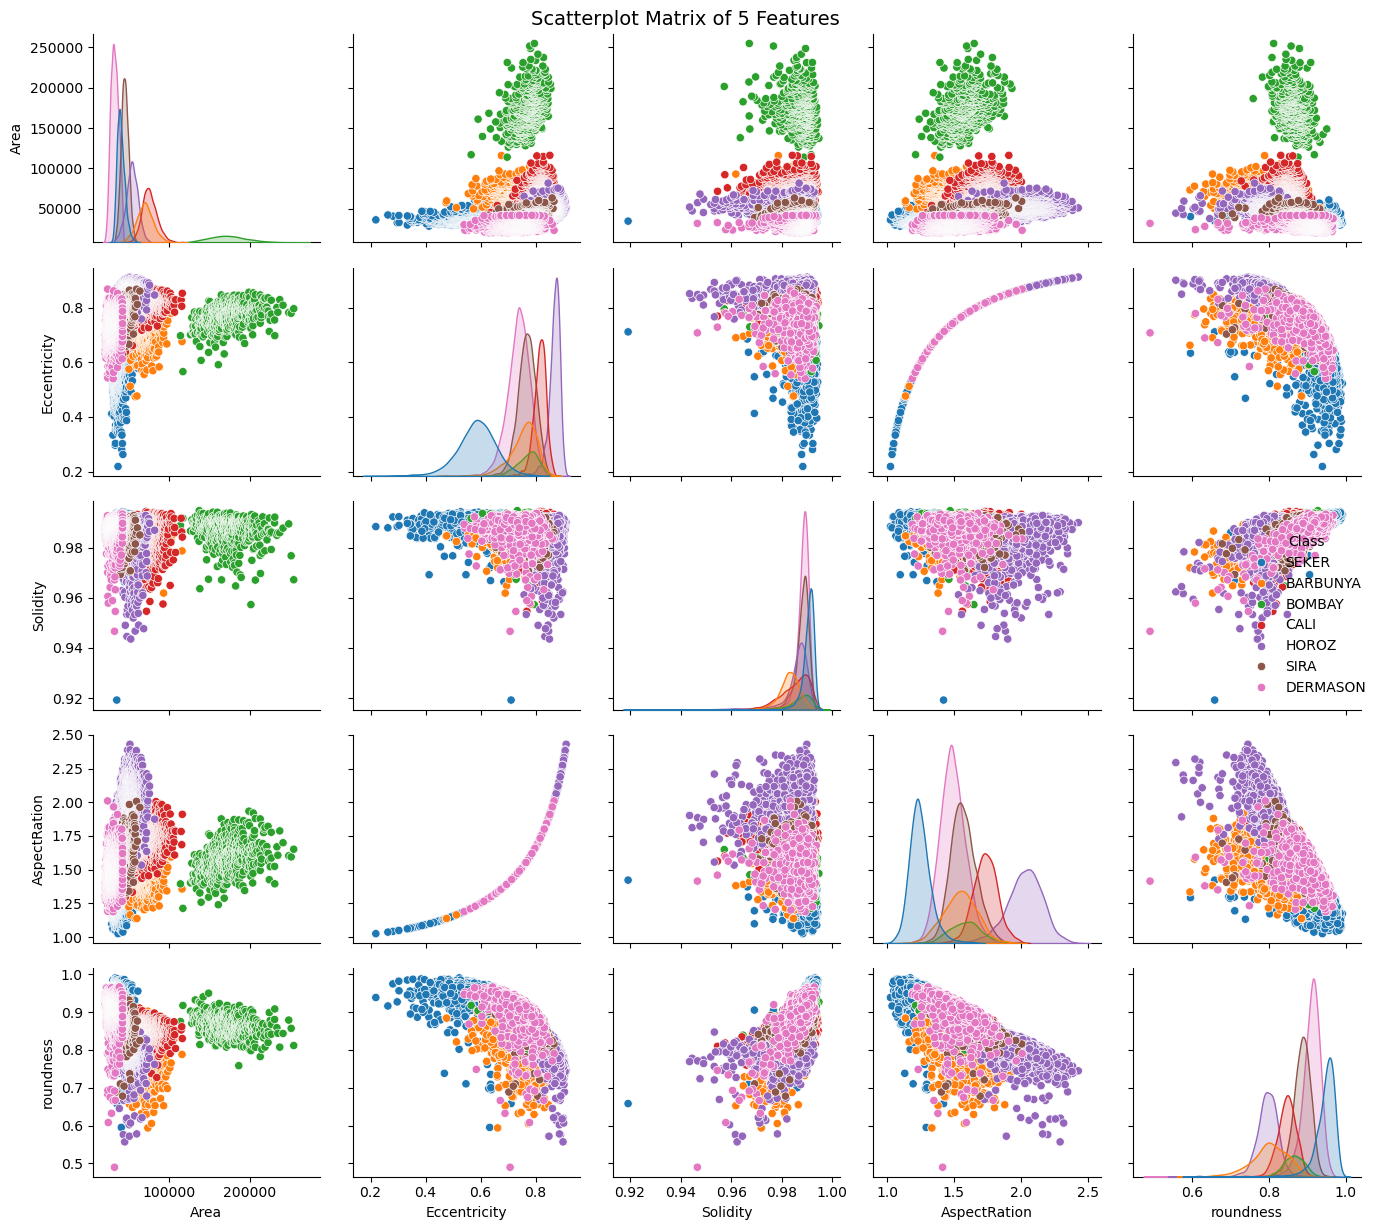

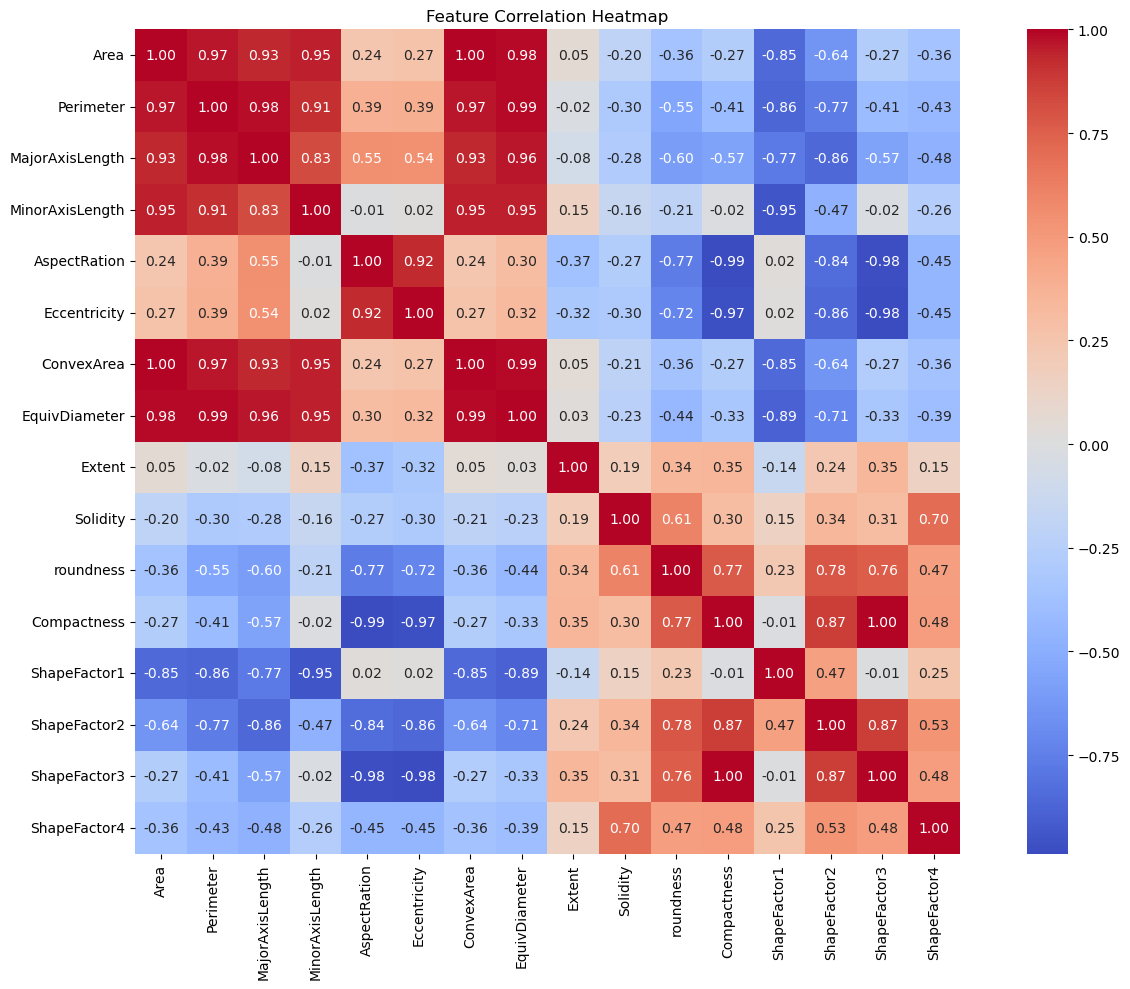

In [109]:
# part 1.1
from pandas.plotting import scatter_matrix

selected_features = ['Area', 'Eccentricity', 'Solidity', 'AspectRation', 'roundness']

sns.pairplot(data=df, vars=selected_features, hue='Class')
plt.suptitle('Scatterplot Matrix of 5 Features', fontsize=14)
plt.tight_layout()
plt.show()

# heatmap
numeric_cols = df.drop('Class', axis=1)
correlation_heatmap = numeric_cols.corr()
plt.figure(figsize=(14,10))
sns.heatmap(correlation_heatmap, square=True, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# from what I noticed from the selected features is there is no redundancy because I chose different features which 
# affect the circle in a different way and in the heatmap it shows how different features are proportional to each other and some are indirectly proportional

In [110]:
# part 1.2
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Class_encoded'] = le.fit_transform(df['Class'])
df.drop('Class', axis=1, inplace=True) 


# checking dupes
# print(df.duplicated().sum())
# theres 68 dupes
df = df.drop_duplicates()
print(f'There are {df.duplicated().sum()} duplicates')

# checking missing values
print('*'*100)

print(df.isnull().sum())

number_of_samples = len(df)
print('*'*100)
print(f'The number of samples is {number_of_samples}')
df.describe()

There are 0 duplicates
****************************************************************************************************
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class_encoded      0
dtype: int64
****************************************************************************************************
The number of samples is 13543


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class_encoded
count,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000
mean,53048.460385,854.993406,319.895602,202.365321,1.581075,0.750315,53767.986709,253.034094,0.749829,0.987152,0.873671,0.800352,0.006561,0.001719,0.644341,0.995078,3.530311
std,29392.438324,214.722684,85.809260,45.051632,0.245245,0.091858,29844.248525,59.307709,0.048939,0.004650,0.059393,0.061464,0.001130,0.000595,0.098653,0.004347,1.832994
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687,0.000000
25%,36282.500000,703.230000,253.086806,175.886357,1.430662,0.715144,36673.000000,214.933277,0.718735,0.985678,0.833410,0.763228,0.005893,0.001158,0.582517,0.993720,2.000000
50%,44580.000000,793.896000,296.404589,192.491117,1.549860,0.763997,45122.000000,238.245711,0.759903,0.988288,0.883490,0.801514,0.006643,0.001700,0.642424,0.996393,3.000000
75%,61382.000000,977.146500,376.312489,217.245403,1.703916,0.809671,62360.000000,279.560351,0.786849,0.990019,0.917031,0.834470,0.007270,0.002173,0.696341,0.997891,5.000000
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733,6.000000


Training Accuracy: 1.00
Test Accuracy: 0.90
Depth:  27
Confusion Matrix:
 [[238   0  17   1   0   3   6]
 [  0 104   0   0   0   0   0]
 [ 15   0 301   0   6   1   3]
 [  0   0   0 640   1  13  55]
 [  4   0  10   5 346   0   7]
 [  7   0   0   9   0 381   9]
 [  4   0   4  58   9  23 429]]


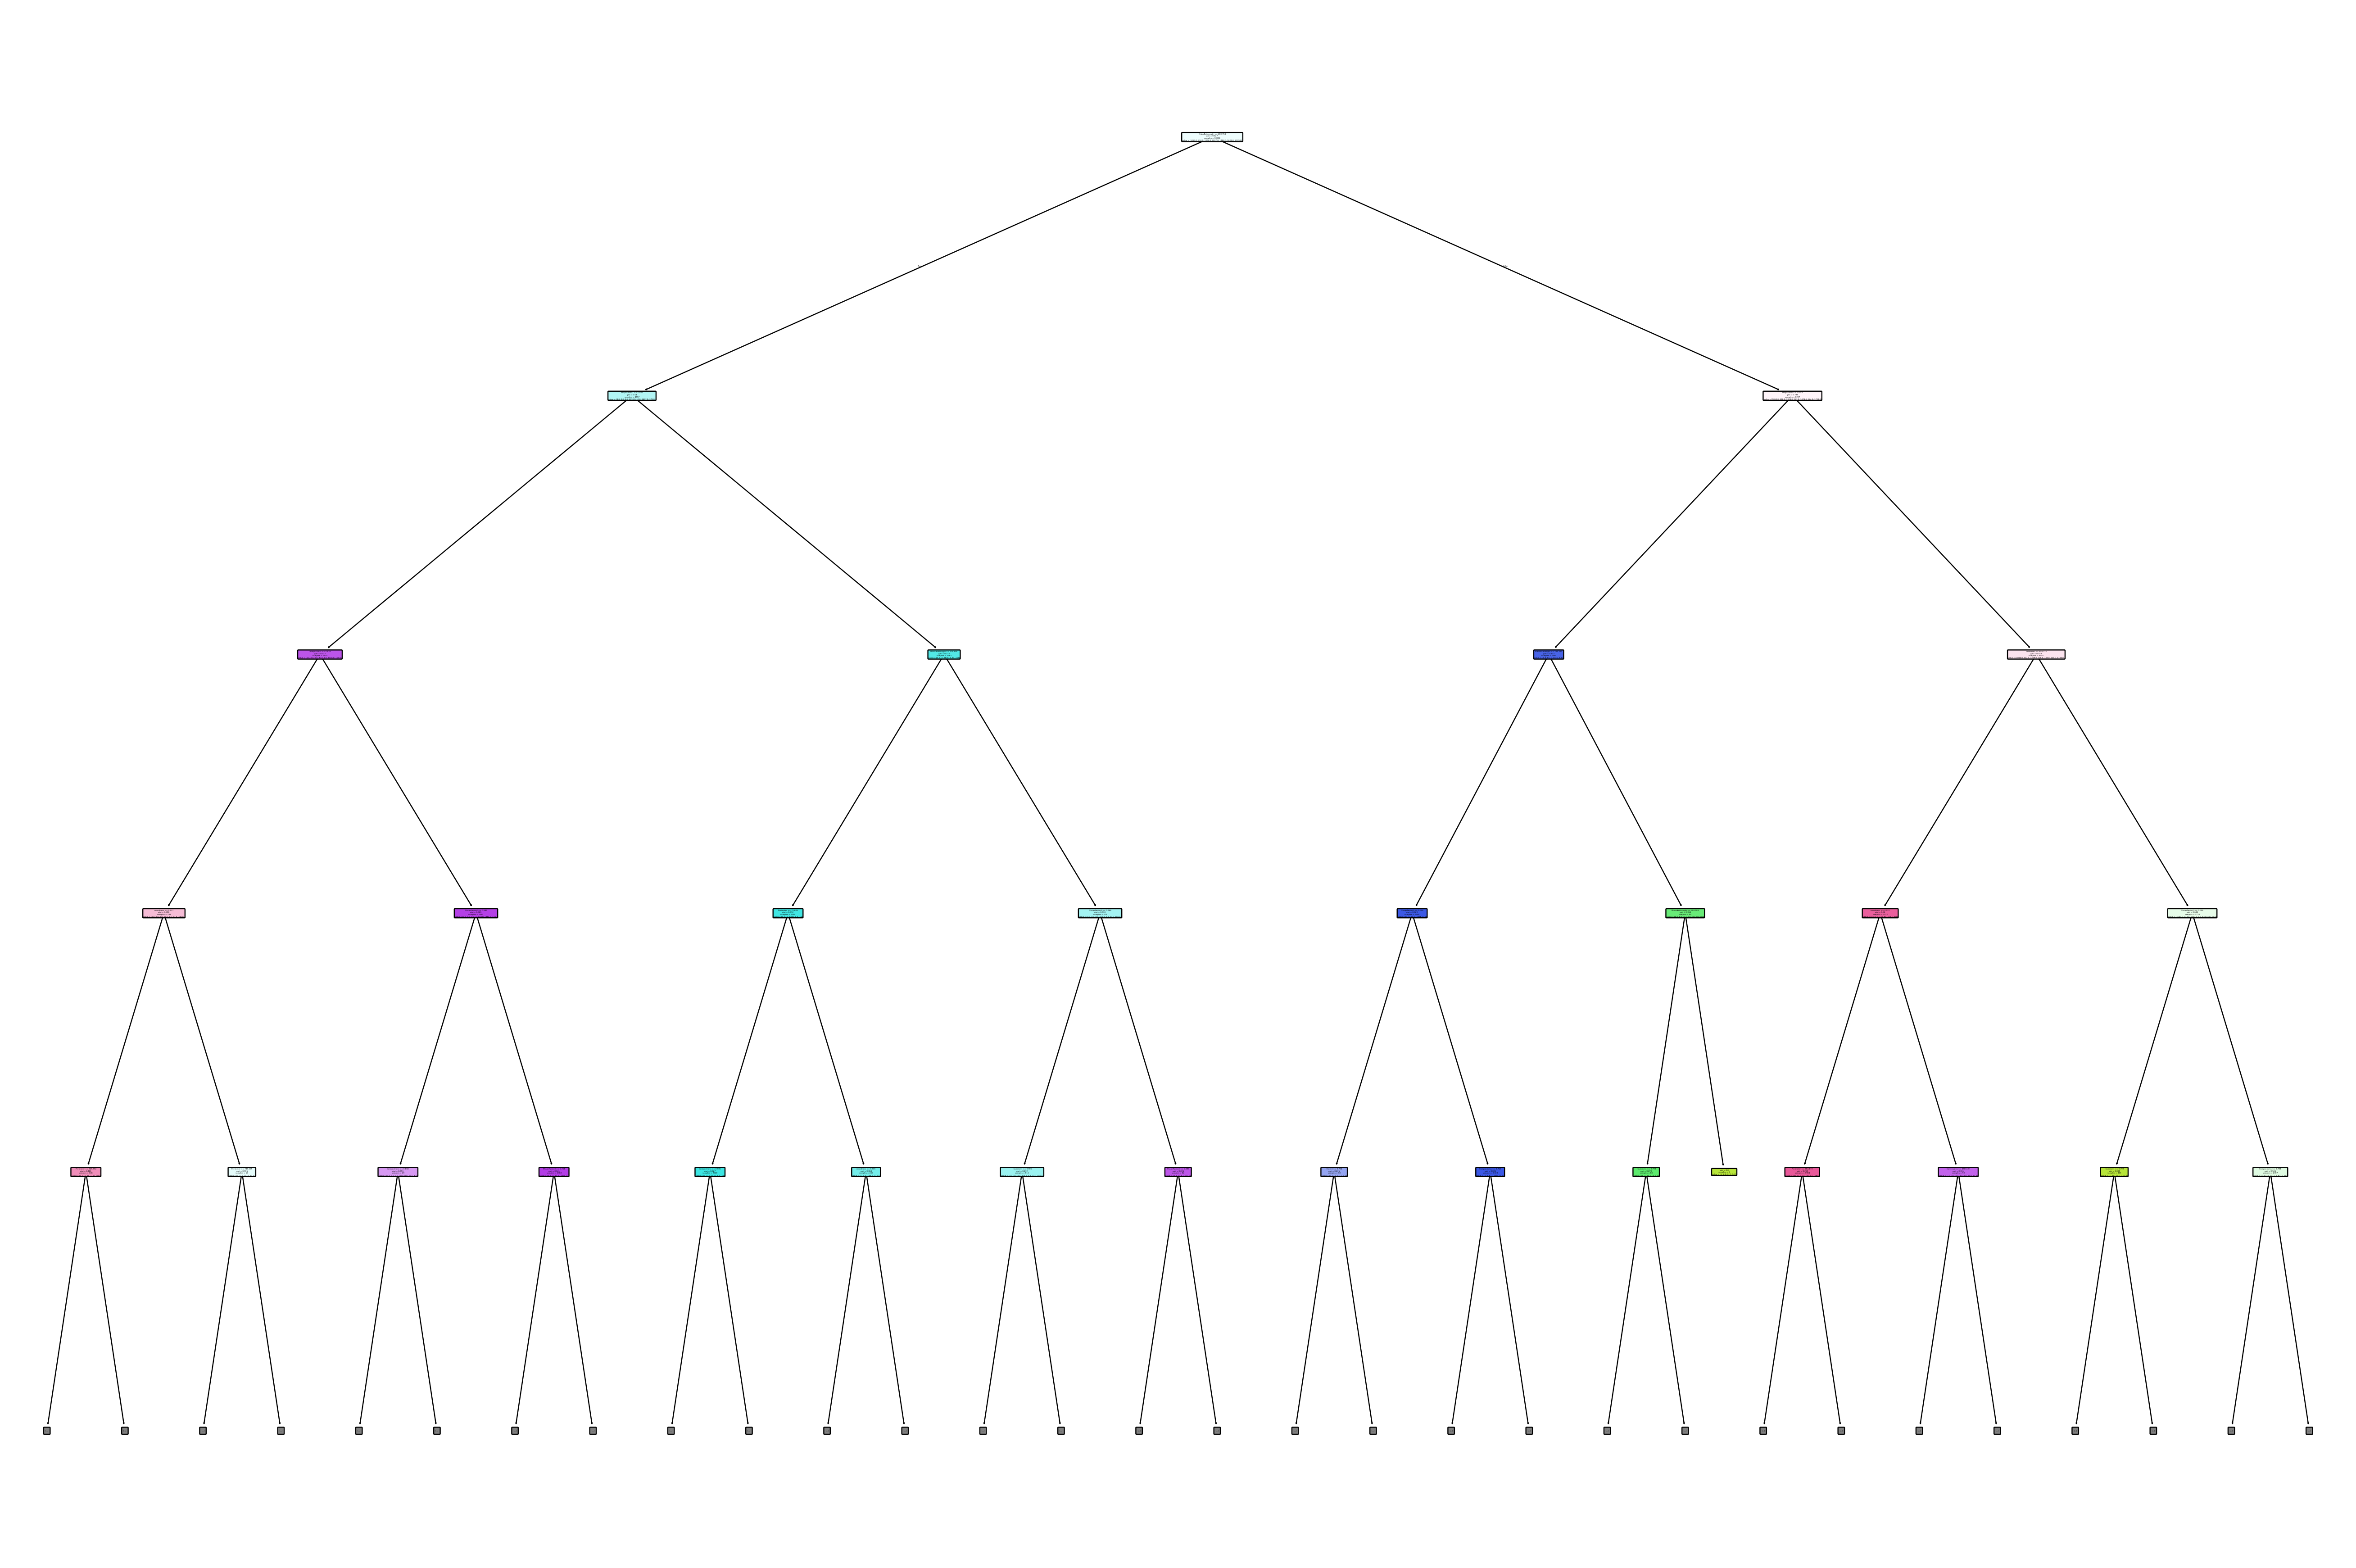

In [111]:
# part 1.3
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import plot_tree

# split the data
X = df.drop('Class_encoded', axis=1)
y = df['Class_encoded']

#testing if it works
# X
# pd.DataFrame(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)

accuracy_train = dtc.score(X_train, y_train)
accuracy_test = dtc.score(X_test, y_test)

print(f"Training Accuracy: {accuracy_train:.2f}")
print(f"Test Accuracy: {accuracy_test:.2f}")


print('Depth: ', dtc.get_depth())
# confusion matrix
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))

# plotting tree
plt.figure(figsize=(30,20), dpi=175)
plot_tree(dtc,
    feature_names=X_train.columns,
    max_depth=4,
    rounded=True,
    filled=True

)
plt.tight_layout()
plt.show()


# From what I can see the top node is the Major Axis Length it splits the data into two the threshold is 280.704 and samples is 10834, 4597 are less pr equal to 280.704 and 6237 are more.
# The second node on the left is Shapefactor1 it splits smaller beans based on their shape 
# third node i Shapefactor3 it splits larger beans based on their shape

Depth:  18
Acuracy:  0.89


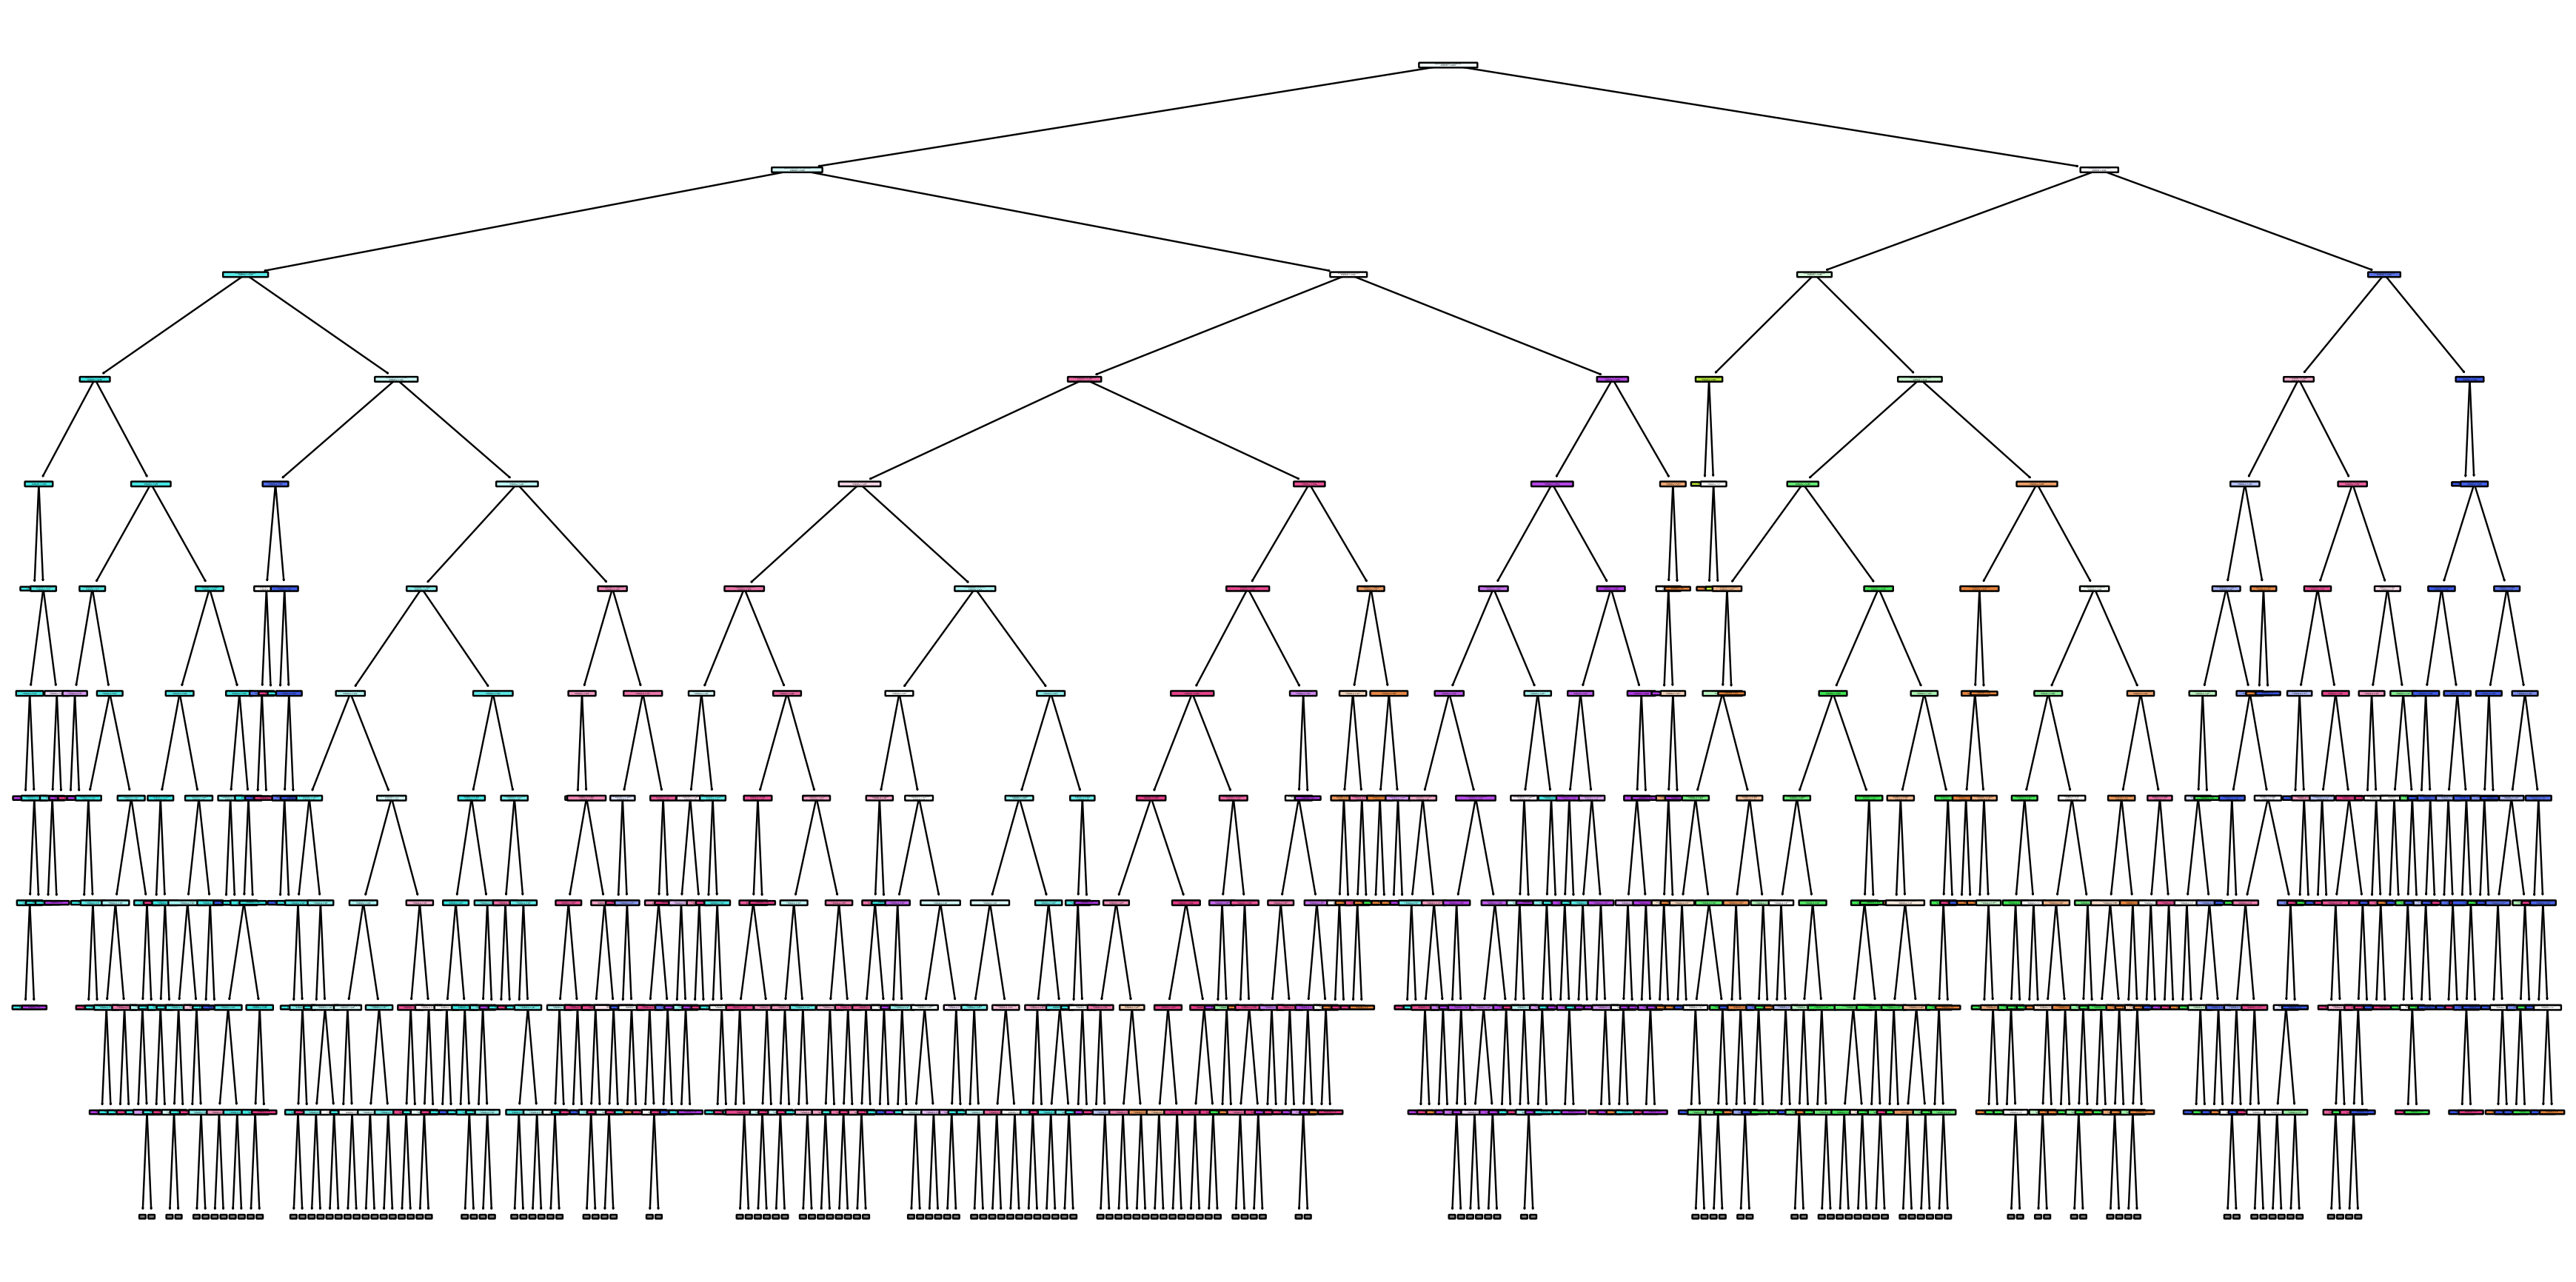

Depth:  18
Acuracy:  0.89


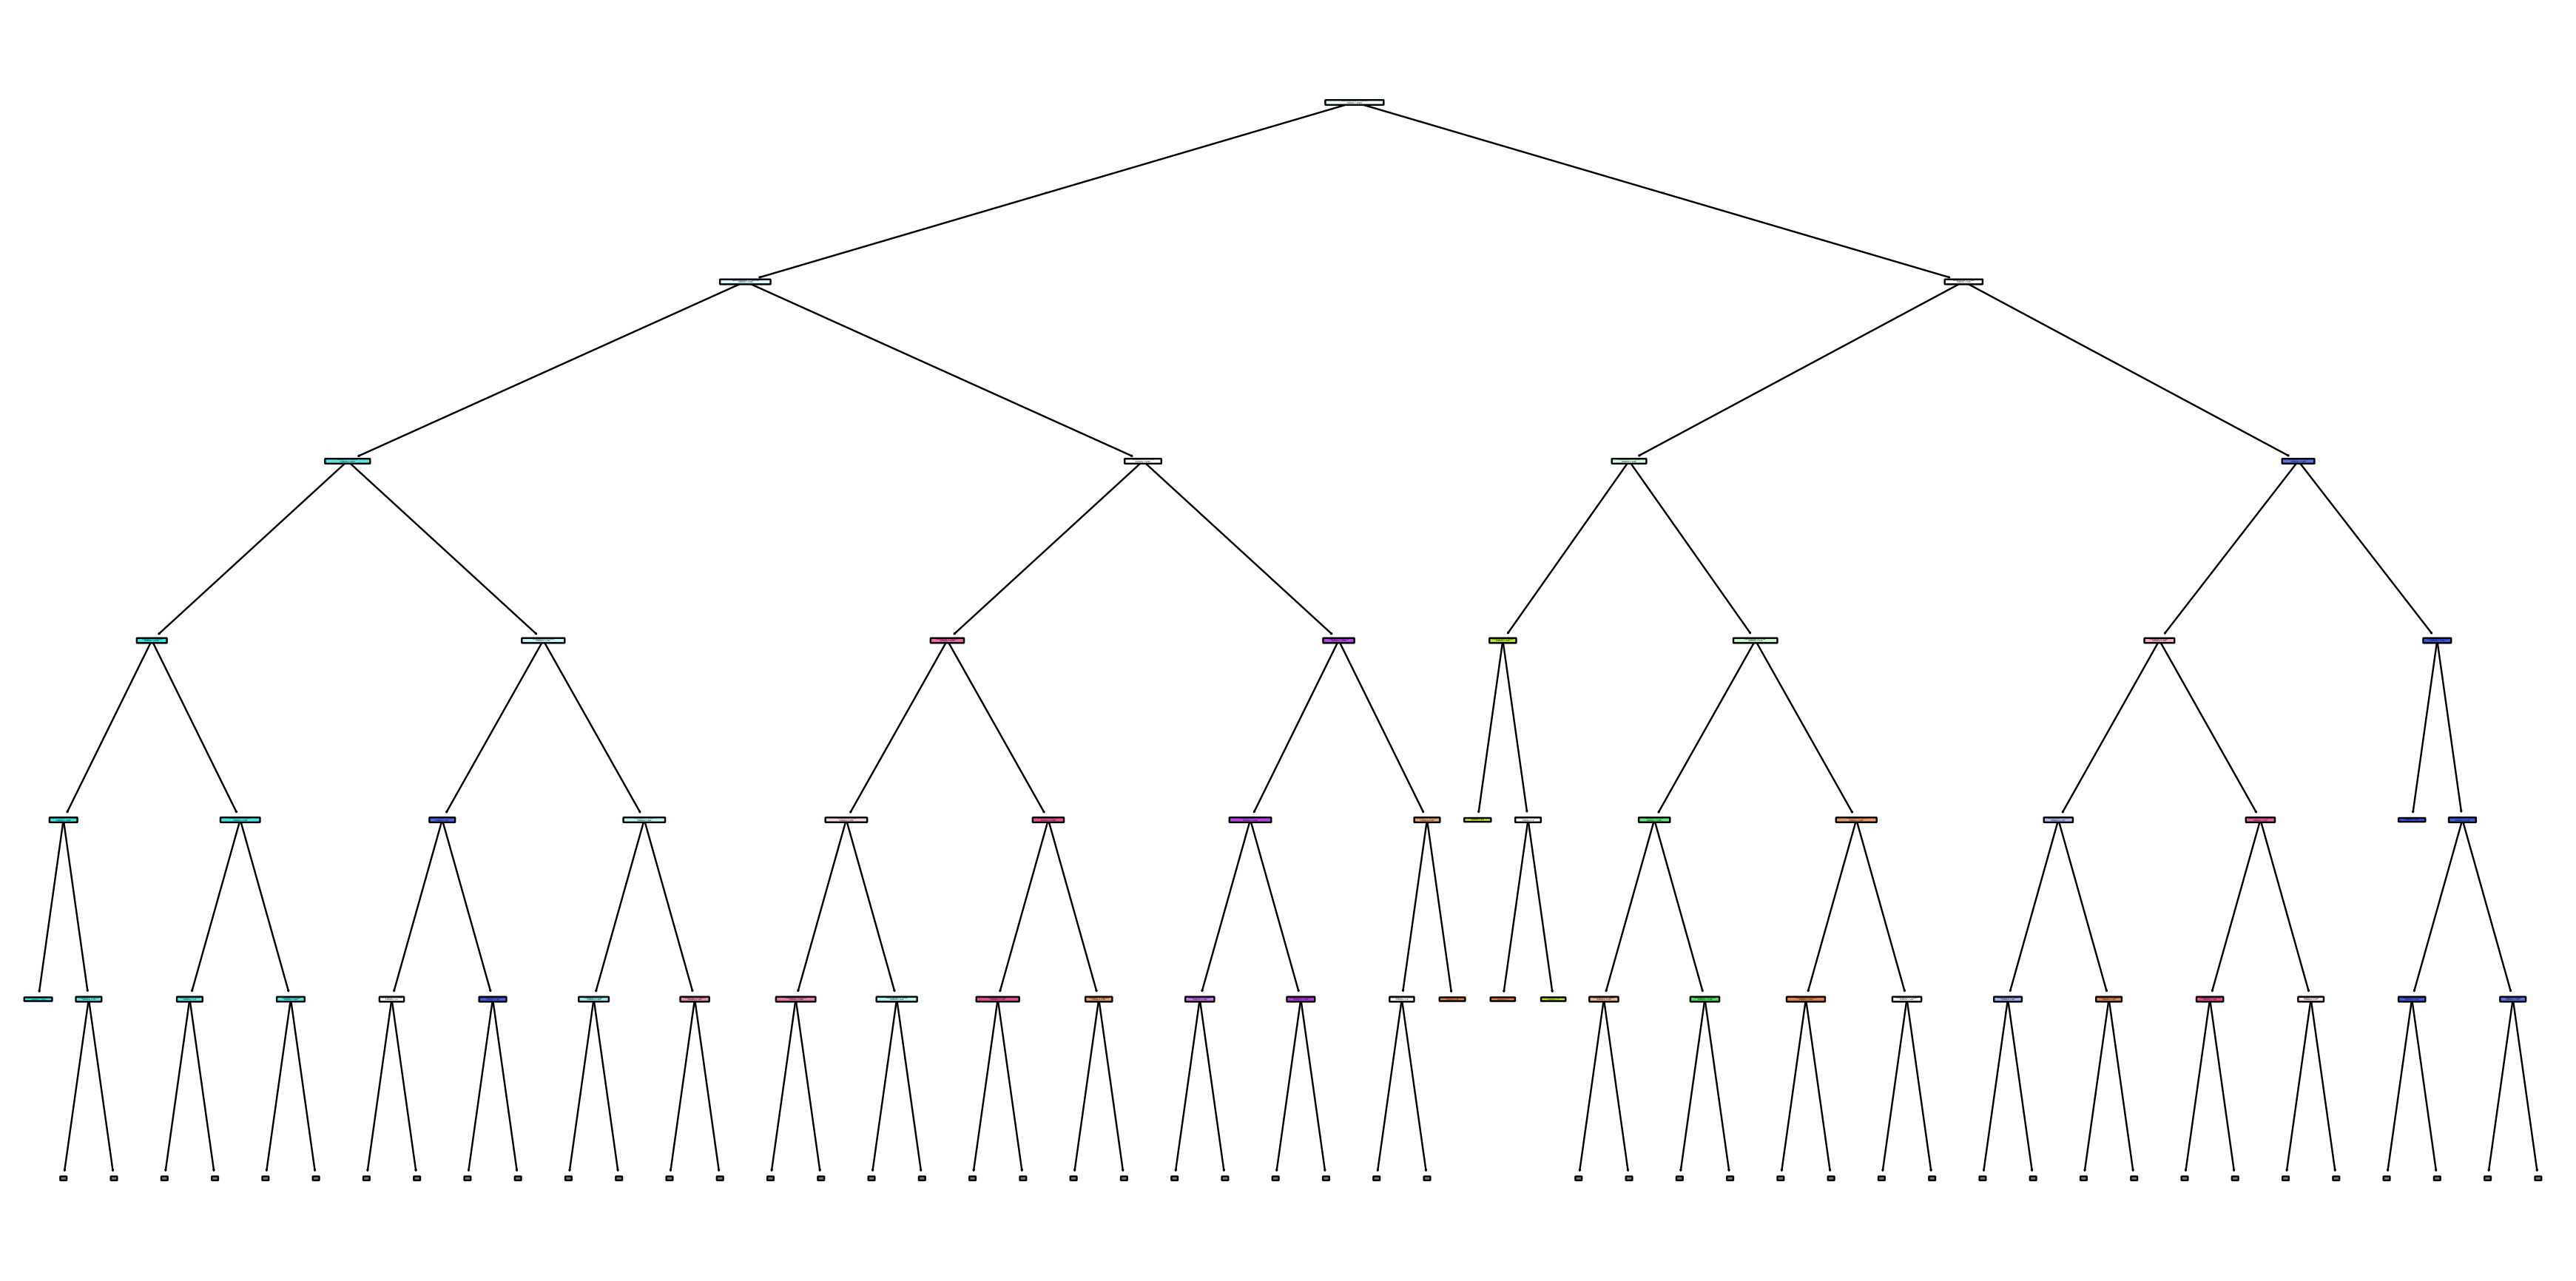

Depth:  18
Acuracy:  0.89


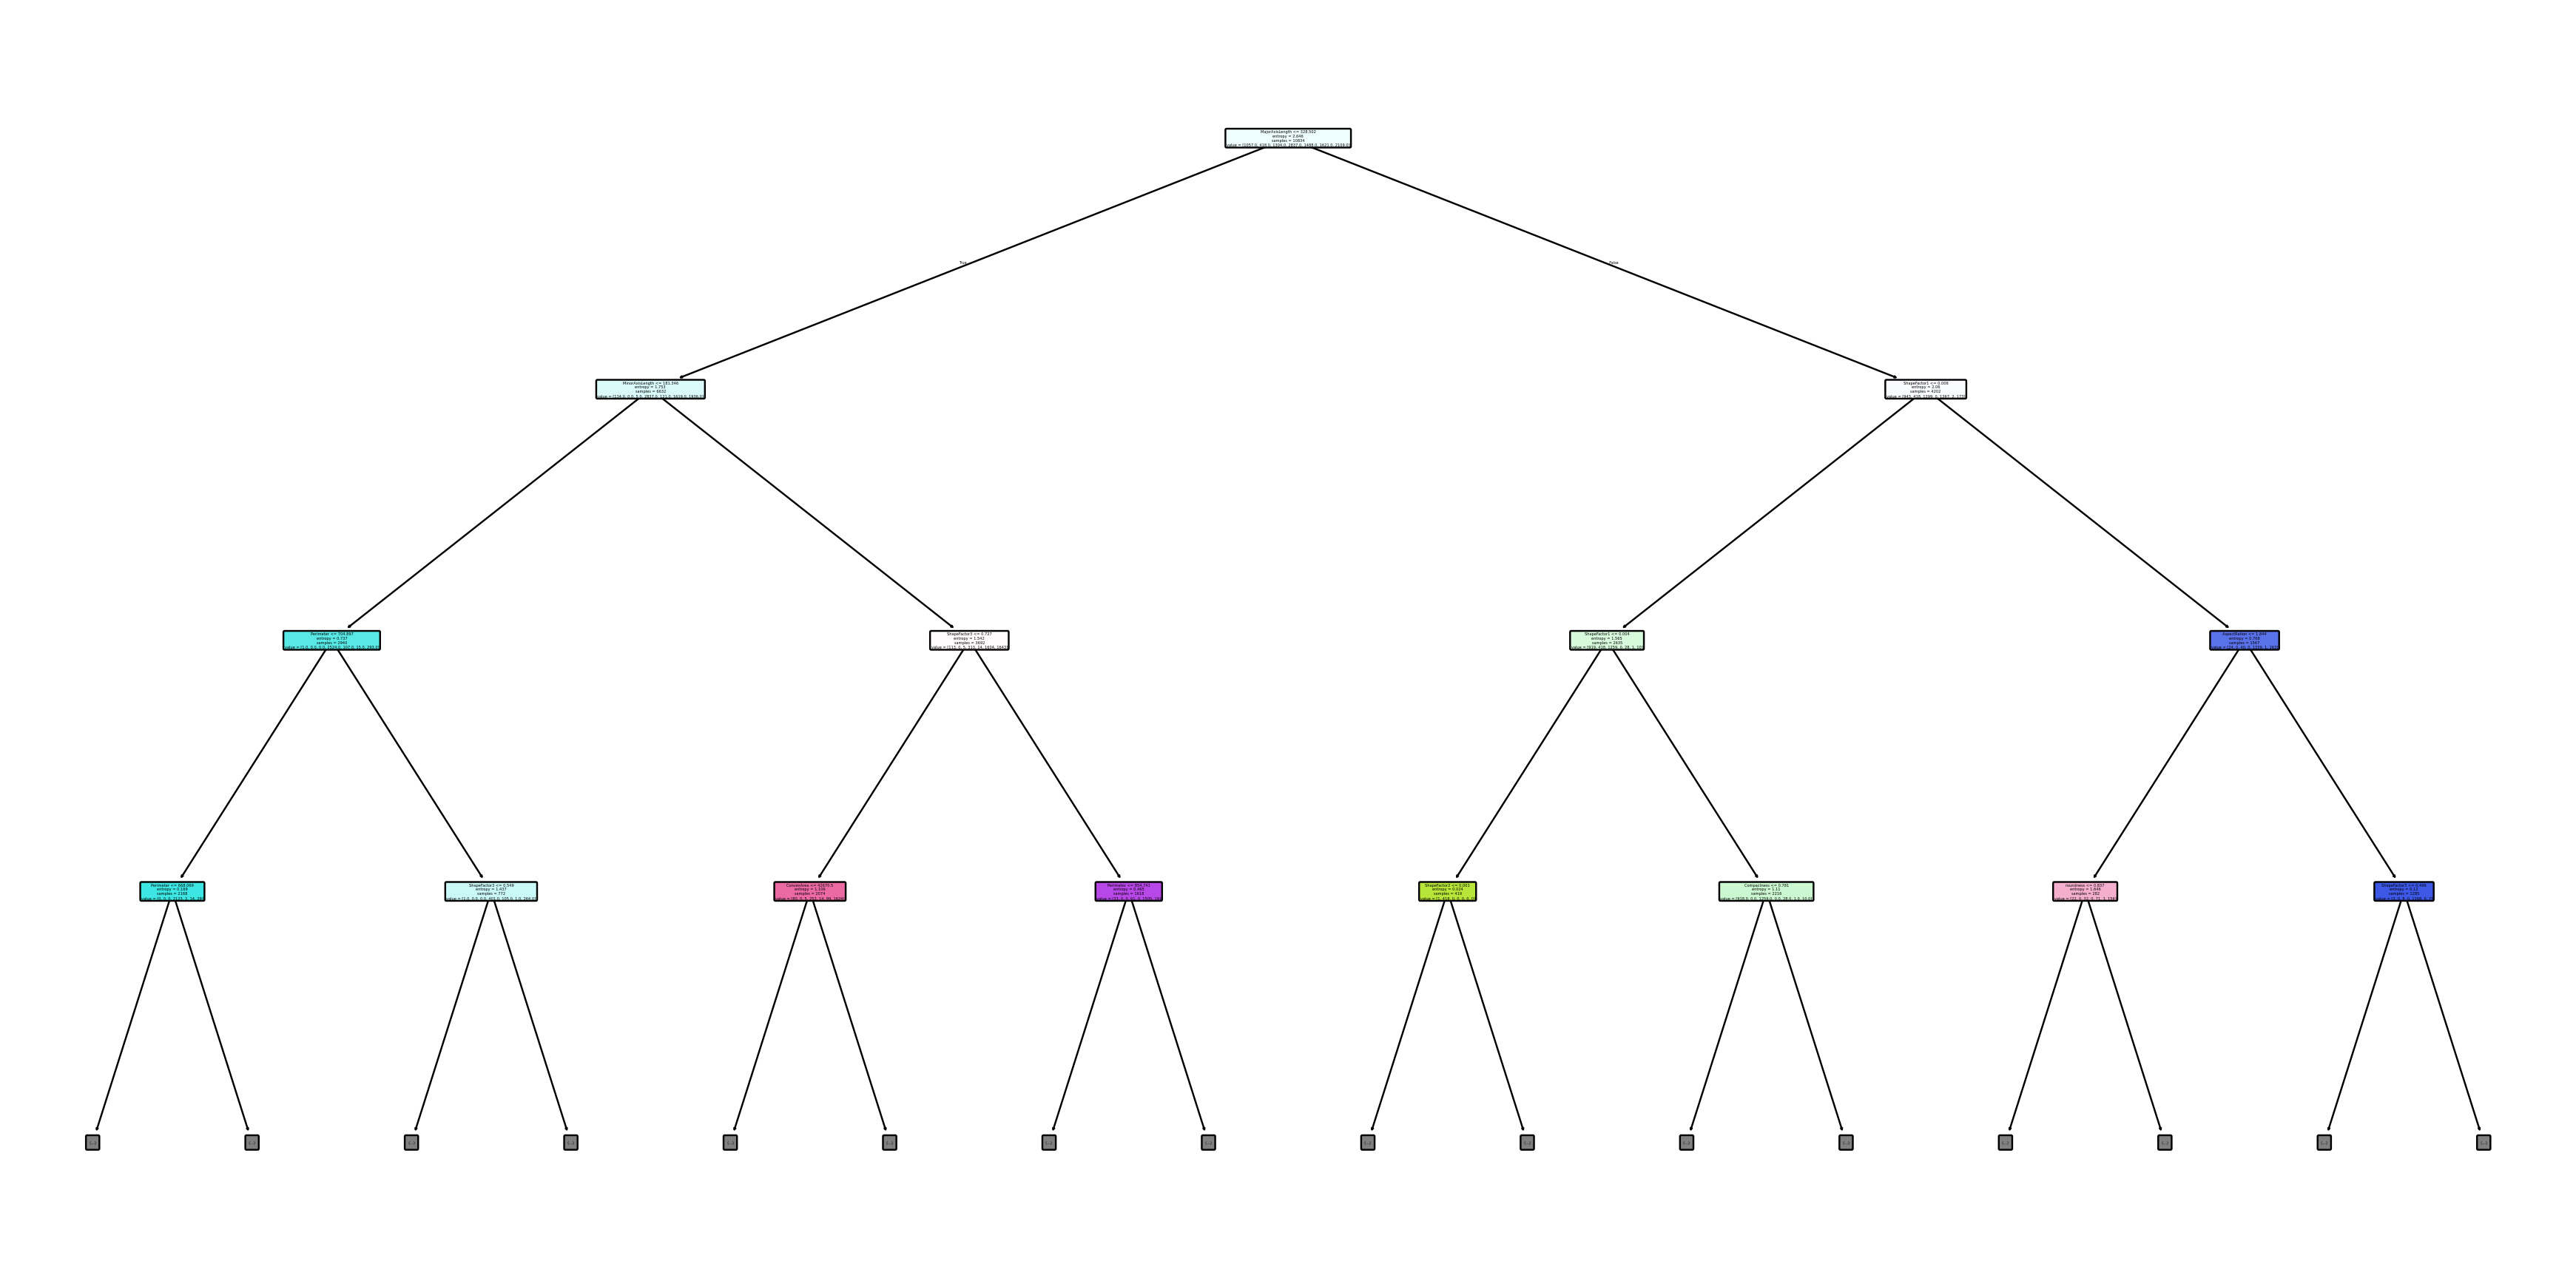

Depth:  18
Acuracy:  0.89


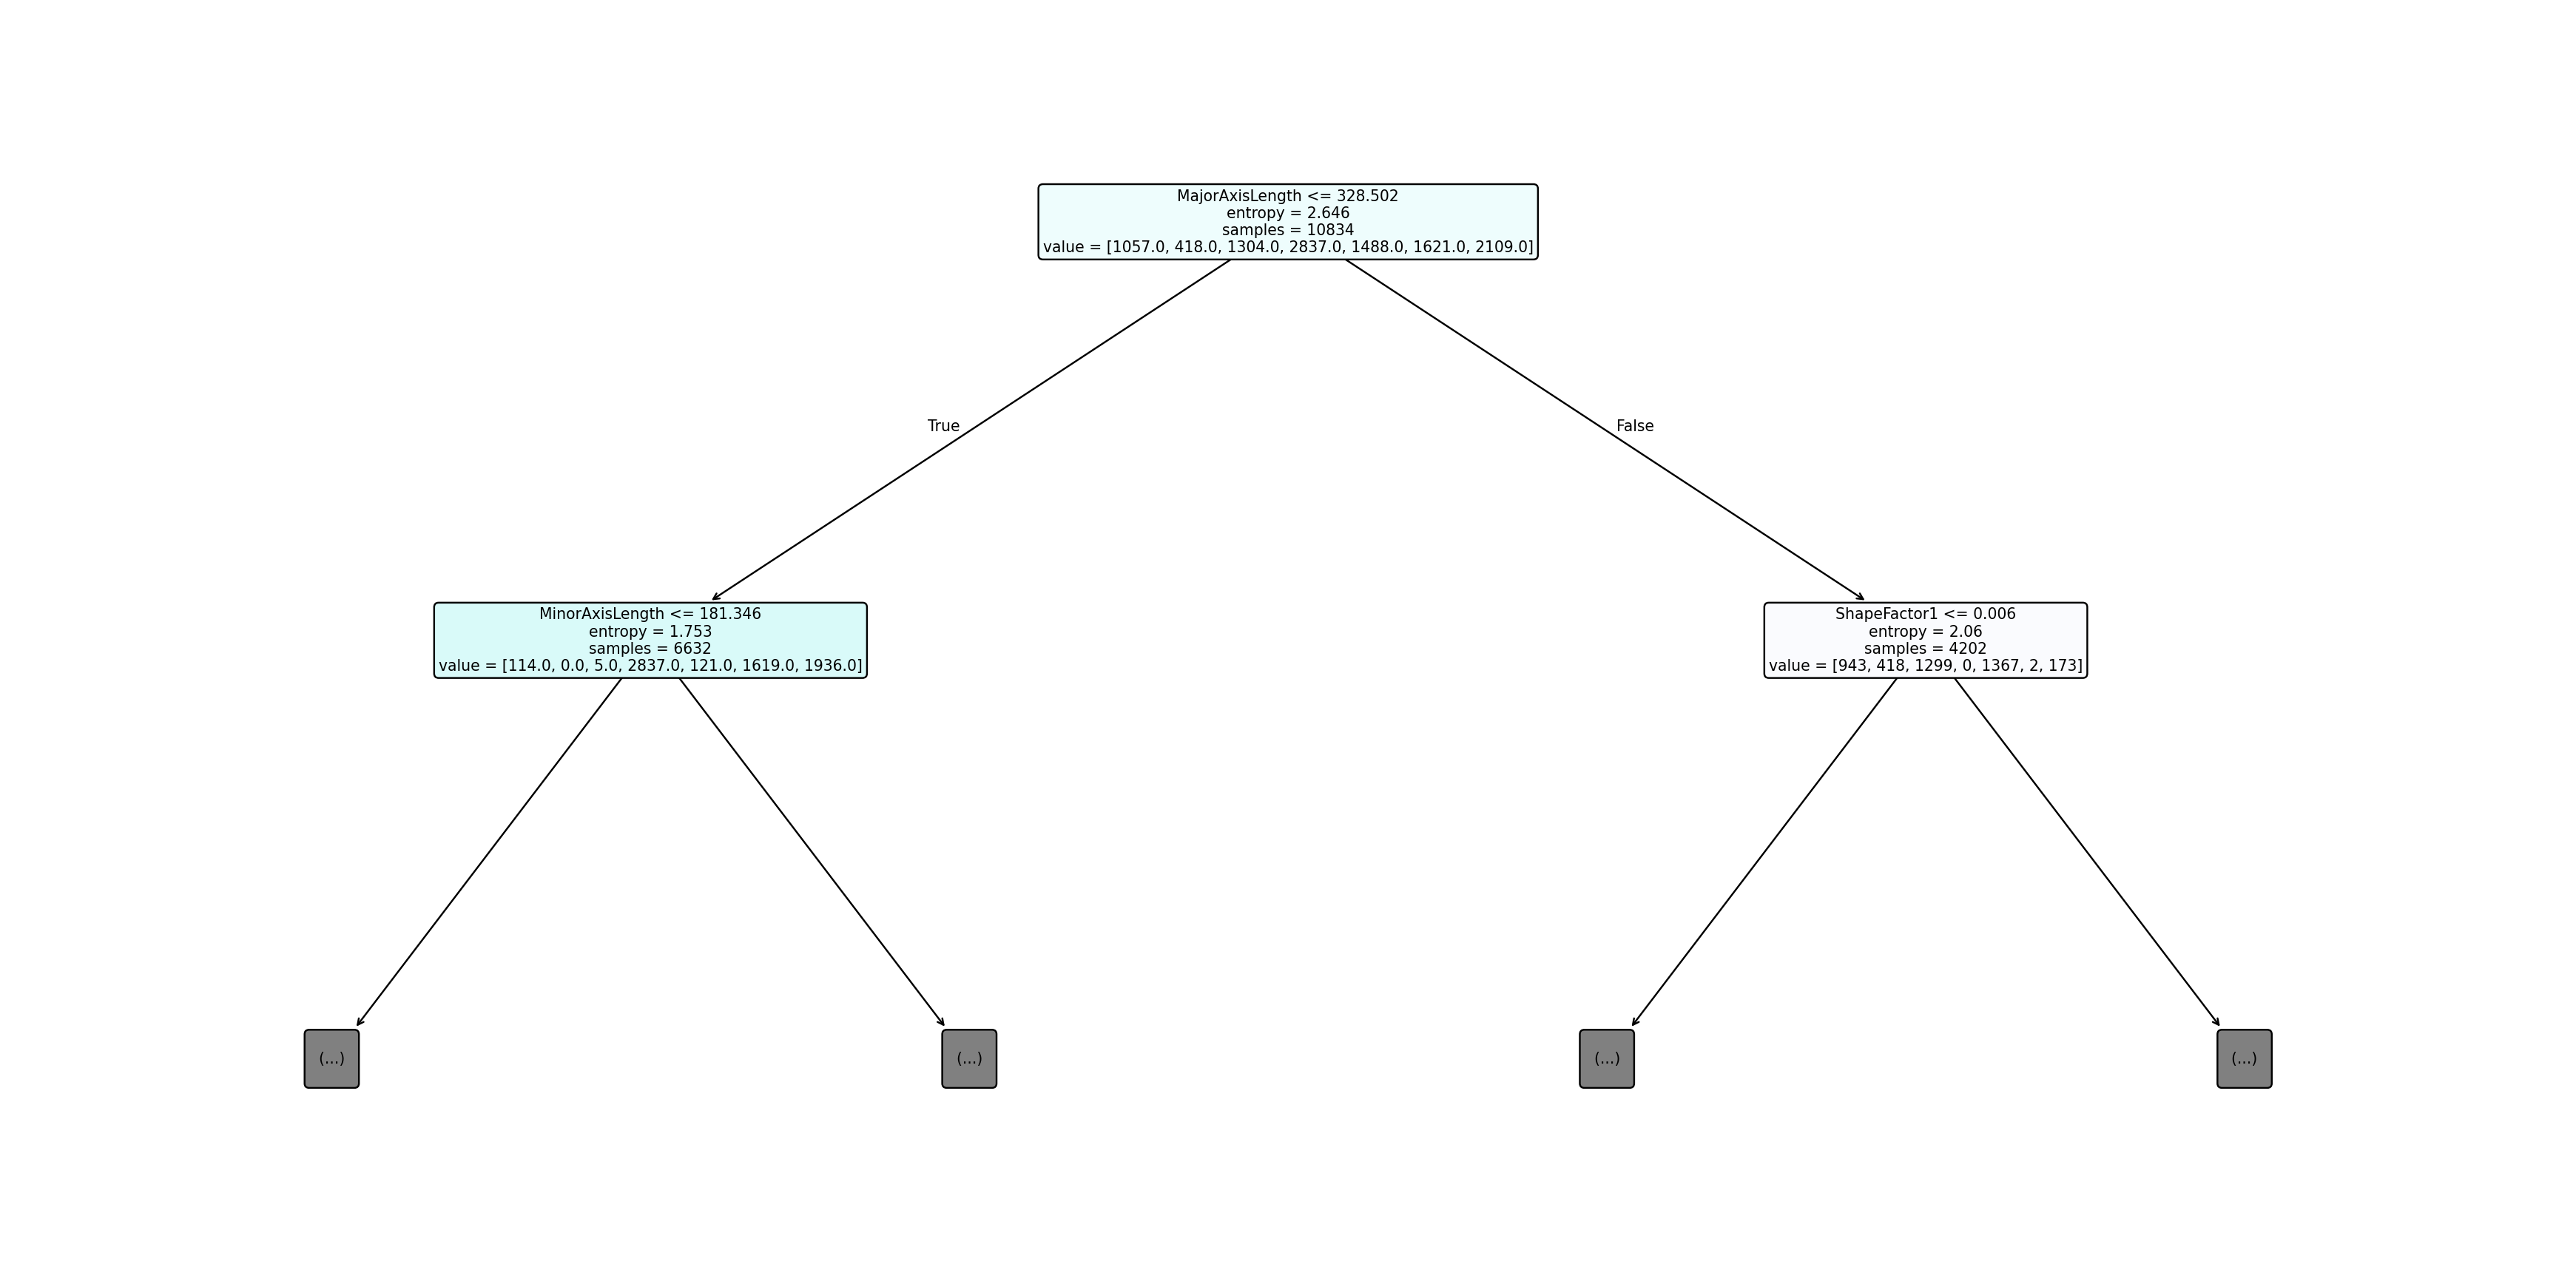

In [112]:
#part 1.4
# entropy and using different values of max depth
dtc_e = DecisionTreeClassifier(criterion='entropy', random_state=42)

def model_summary(model, X_train, y_train, X_test, y_test, max_depth):
    model.fit(X_train, y_train)
    print('Depth: ', model.get_depth())
    print('Acuracy: ', round(model.score(X_test,y_test),2))

    
    plt.figure(figsize=(20,10), dpi=175)
    plot_tree(model,
        feature_names=X_train.columns,
        max_depth=max_depth,
        rounded=True,
        filled=True

    )
    plt.tight_layout()
    plt.show()
    
model_summary(dtc_e, X_train, y_train, X_test, y_test,10)
model_summary(dtc_e, X_train, y_train, X_test, y_test,5)
model_summary(dtc_e, X_train, y_train, X_test, y_test,3)
model_summary(dtc_e, X_train, y_train, X_test, y_test,1)
    

Depth:  27
Acuracy:  0.9


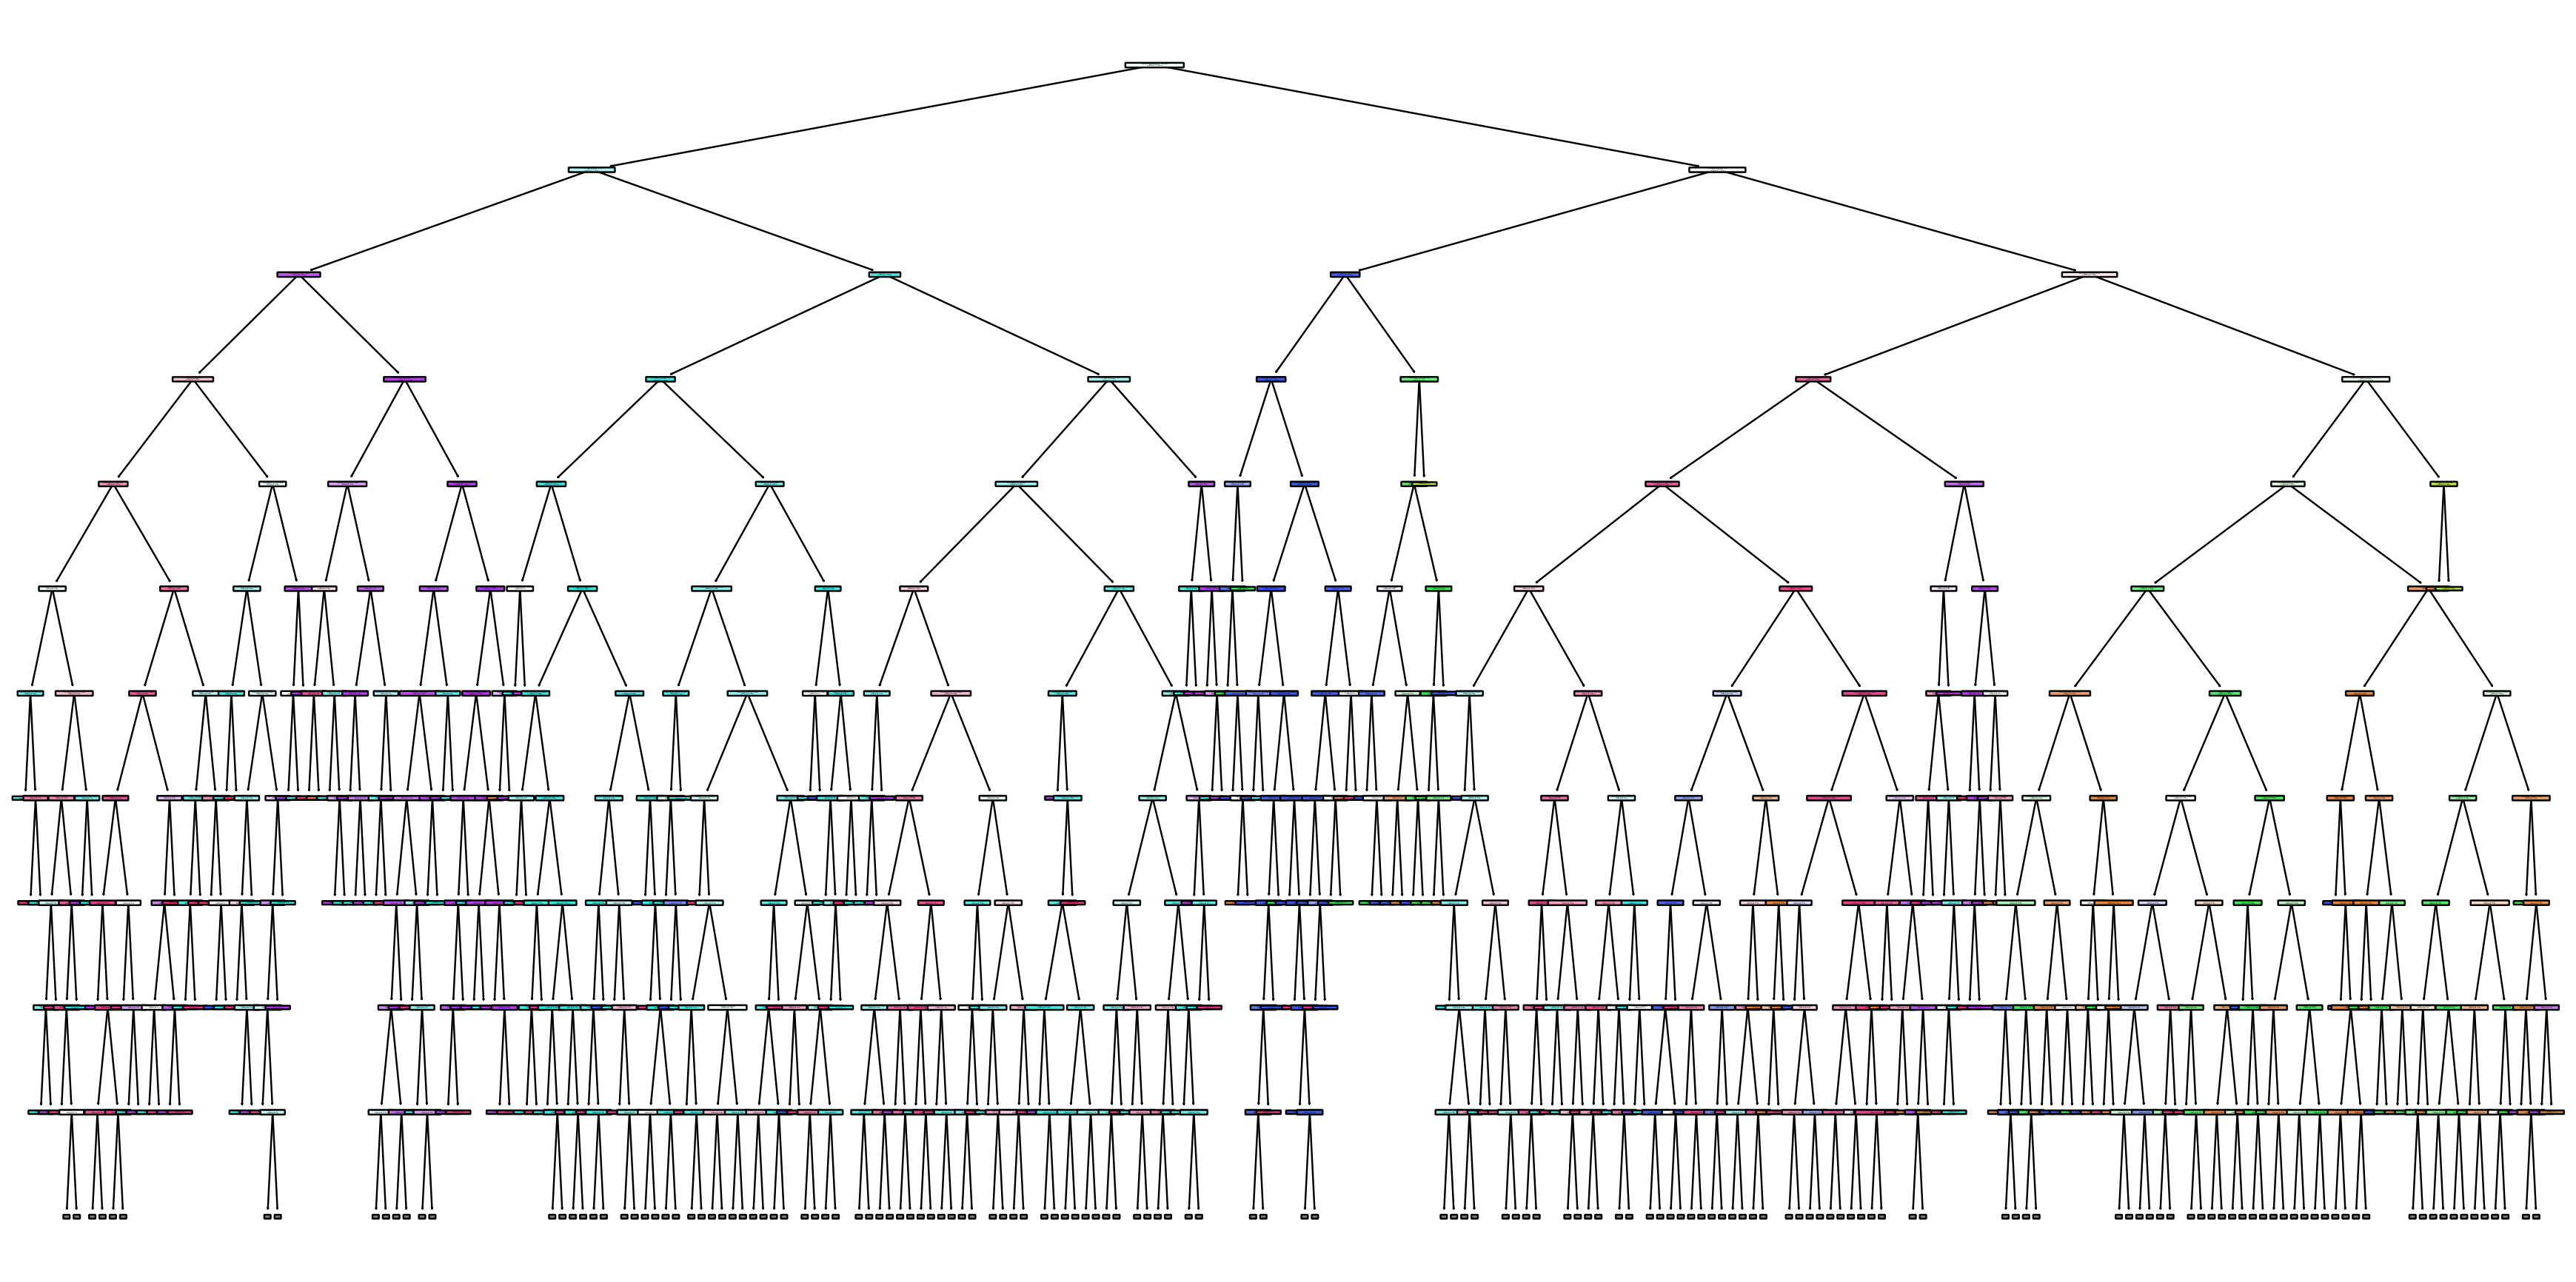

Depth:  27
Acuracy:  0.9


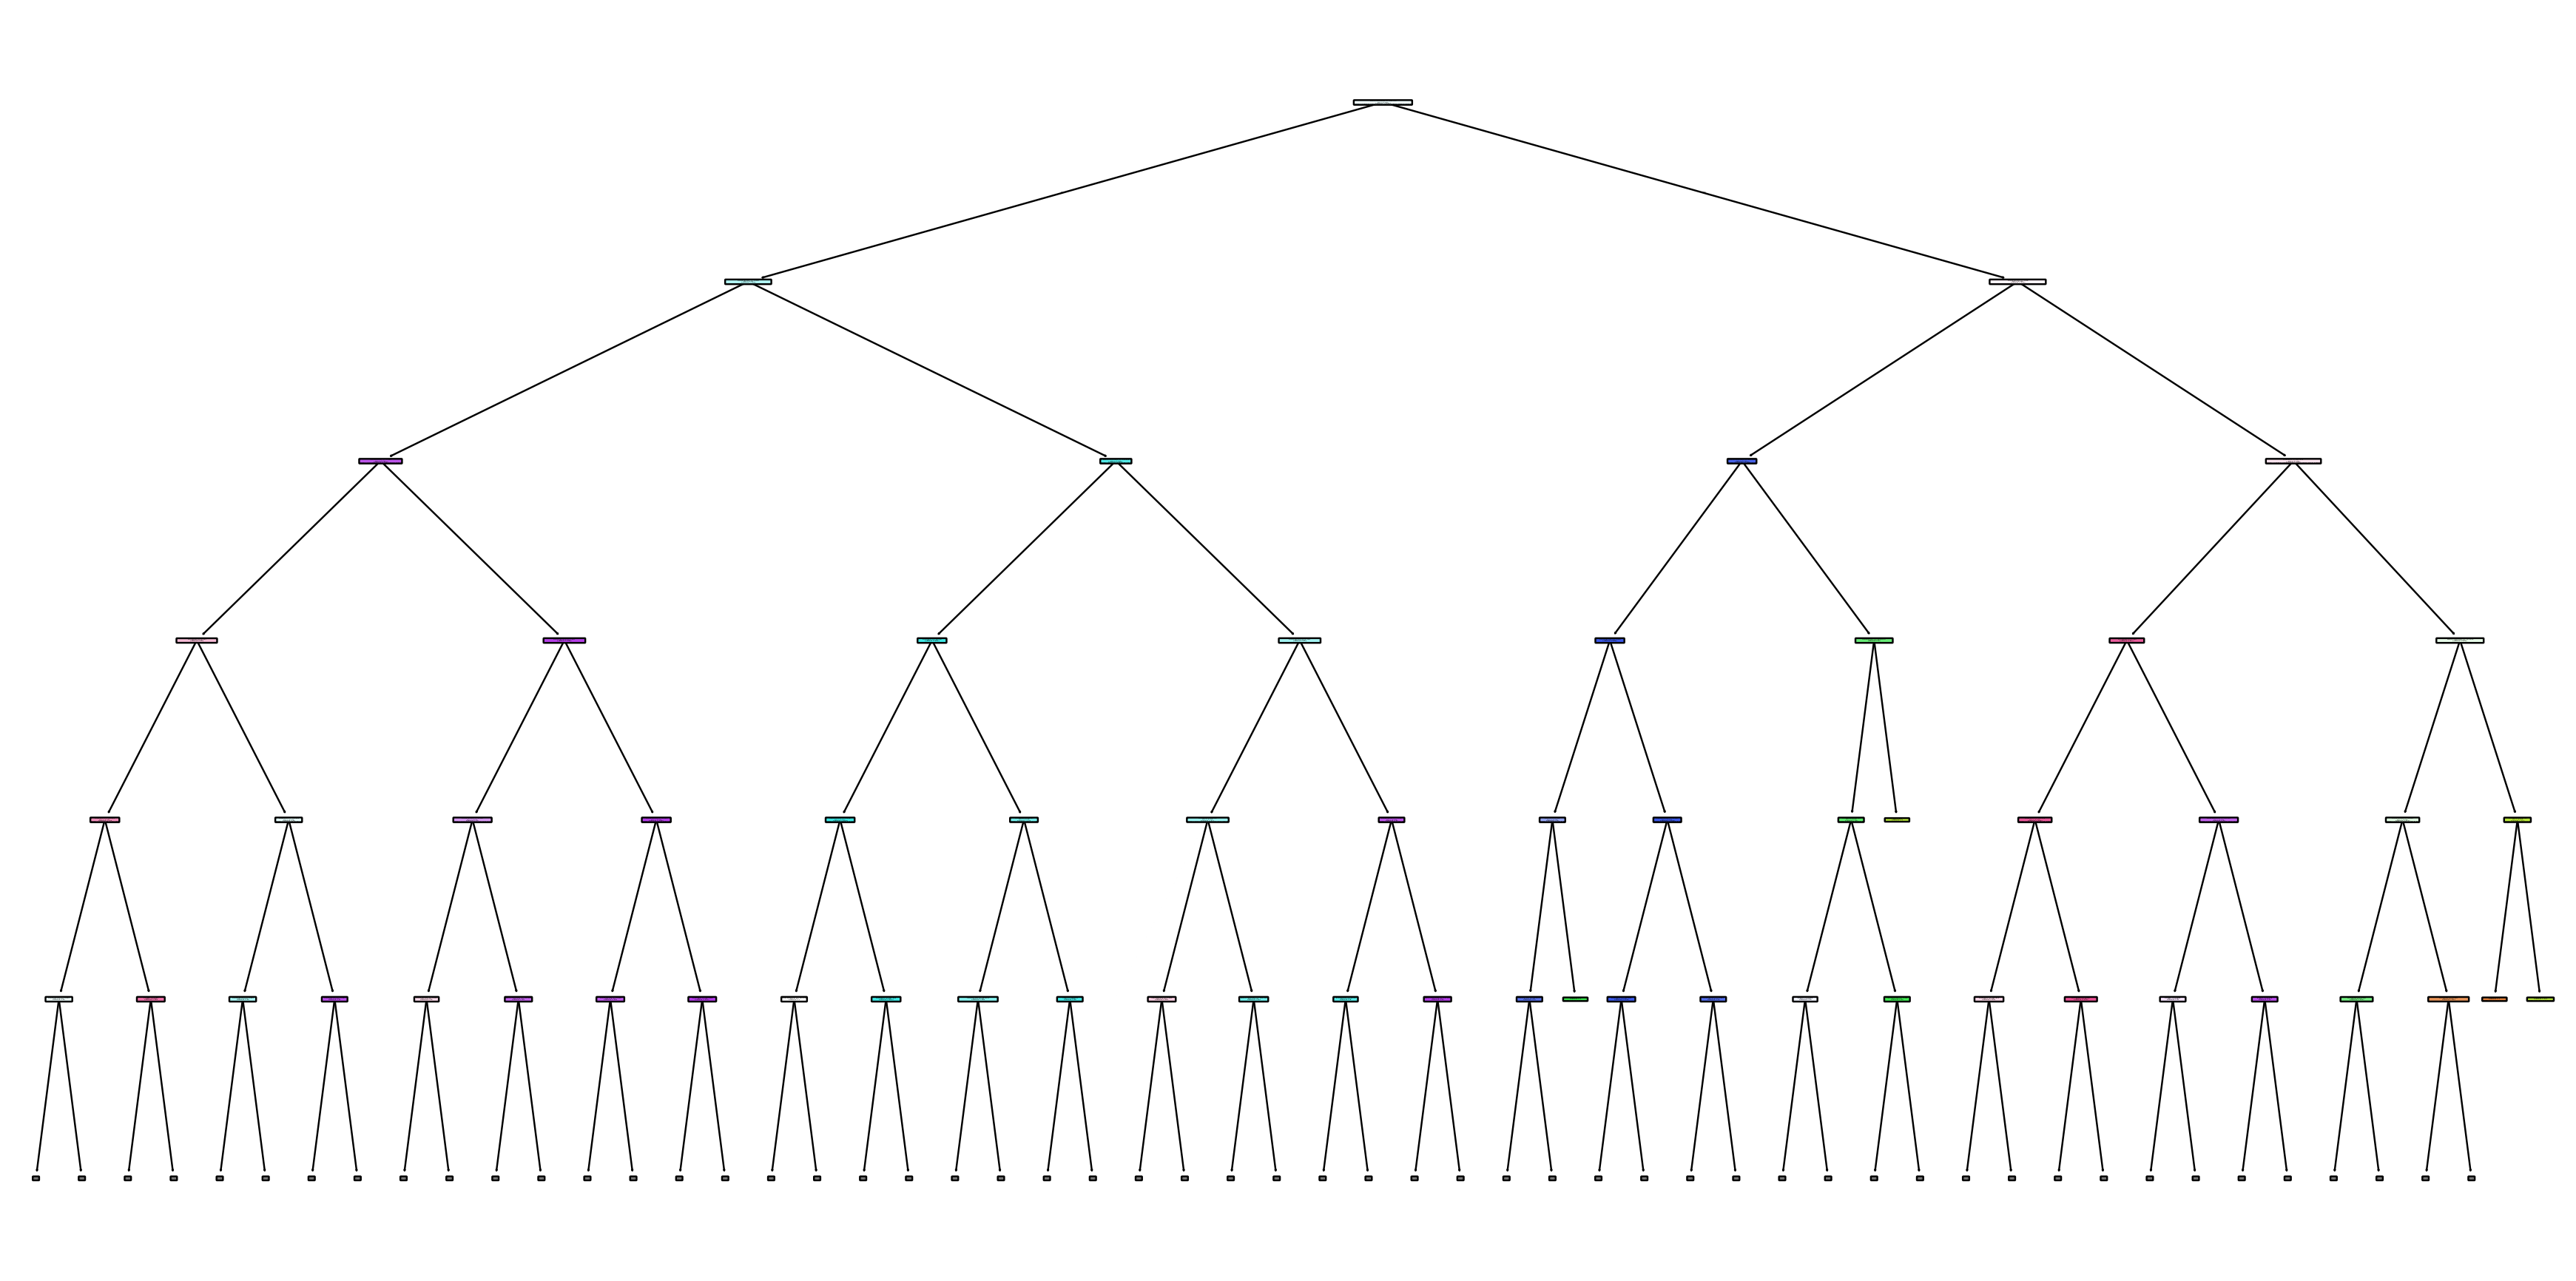

Depth:  27
Acuracy:  0.9


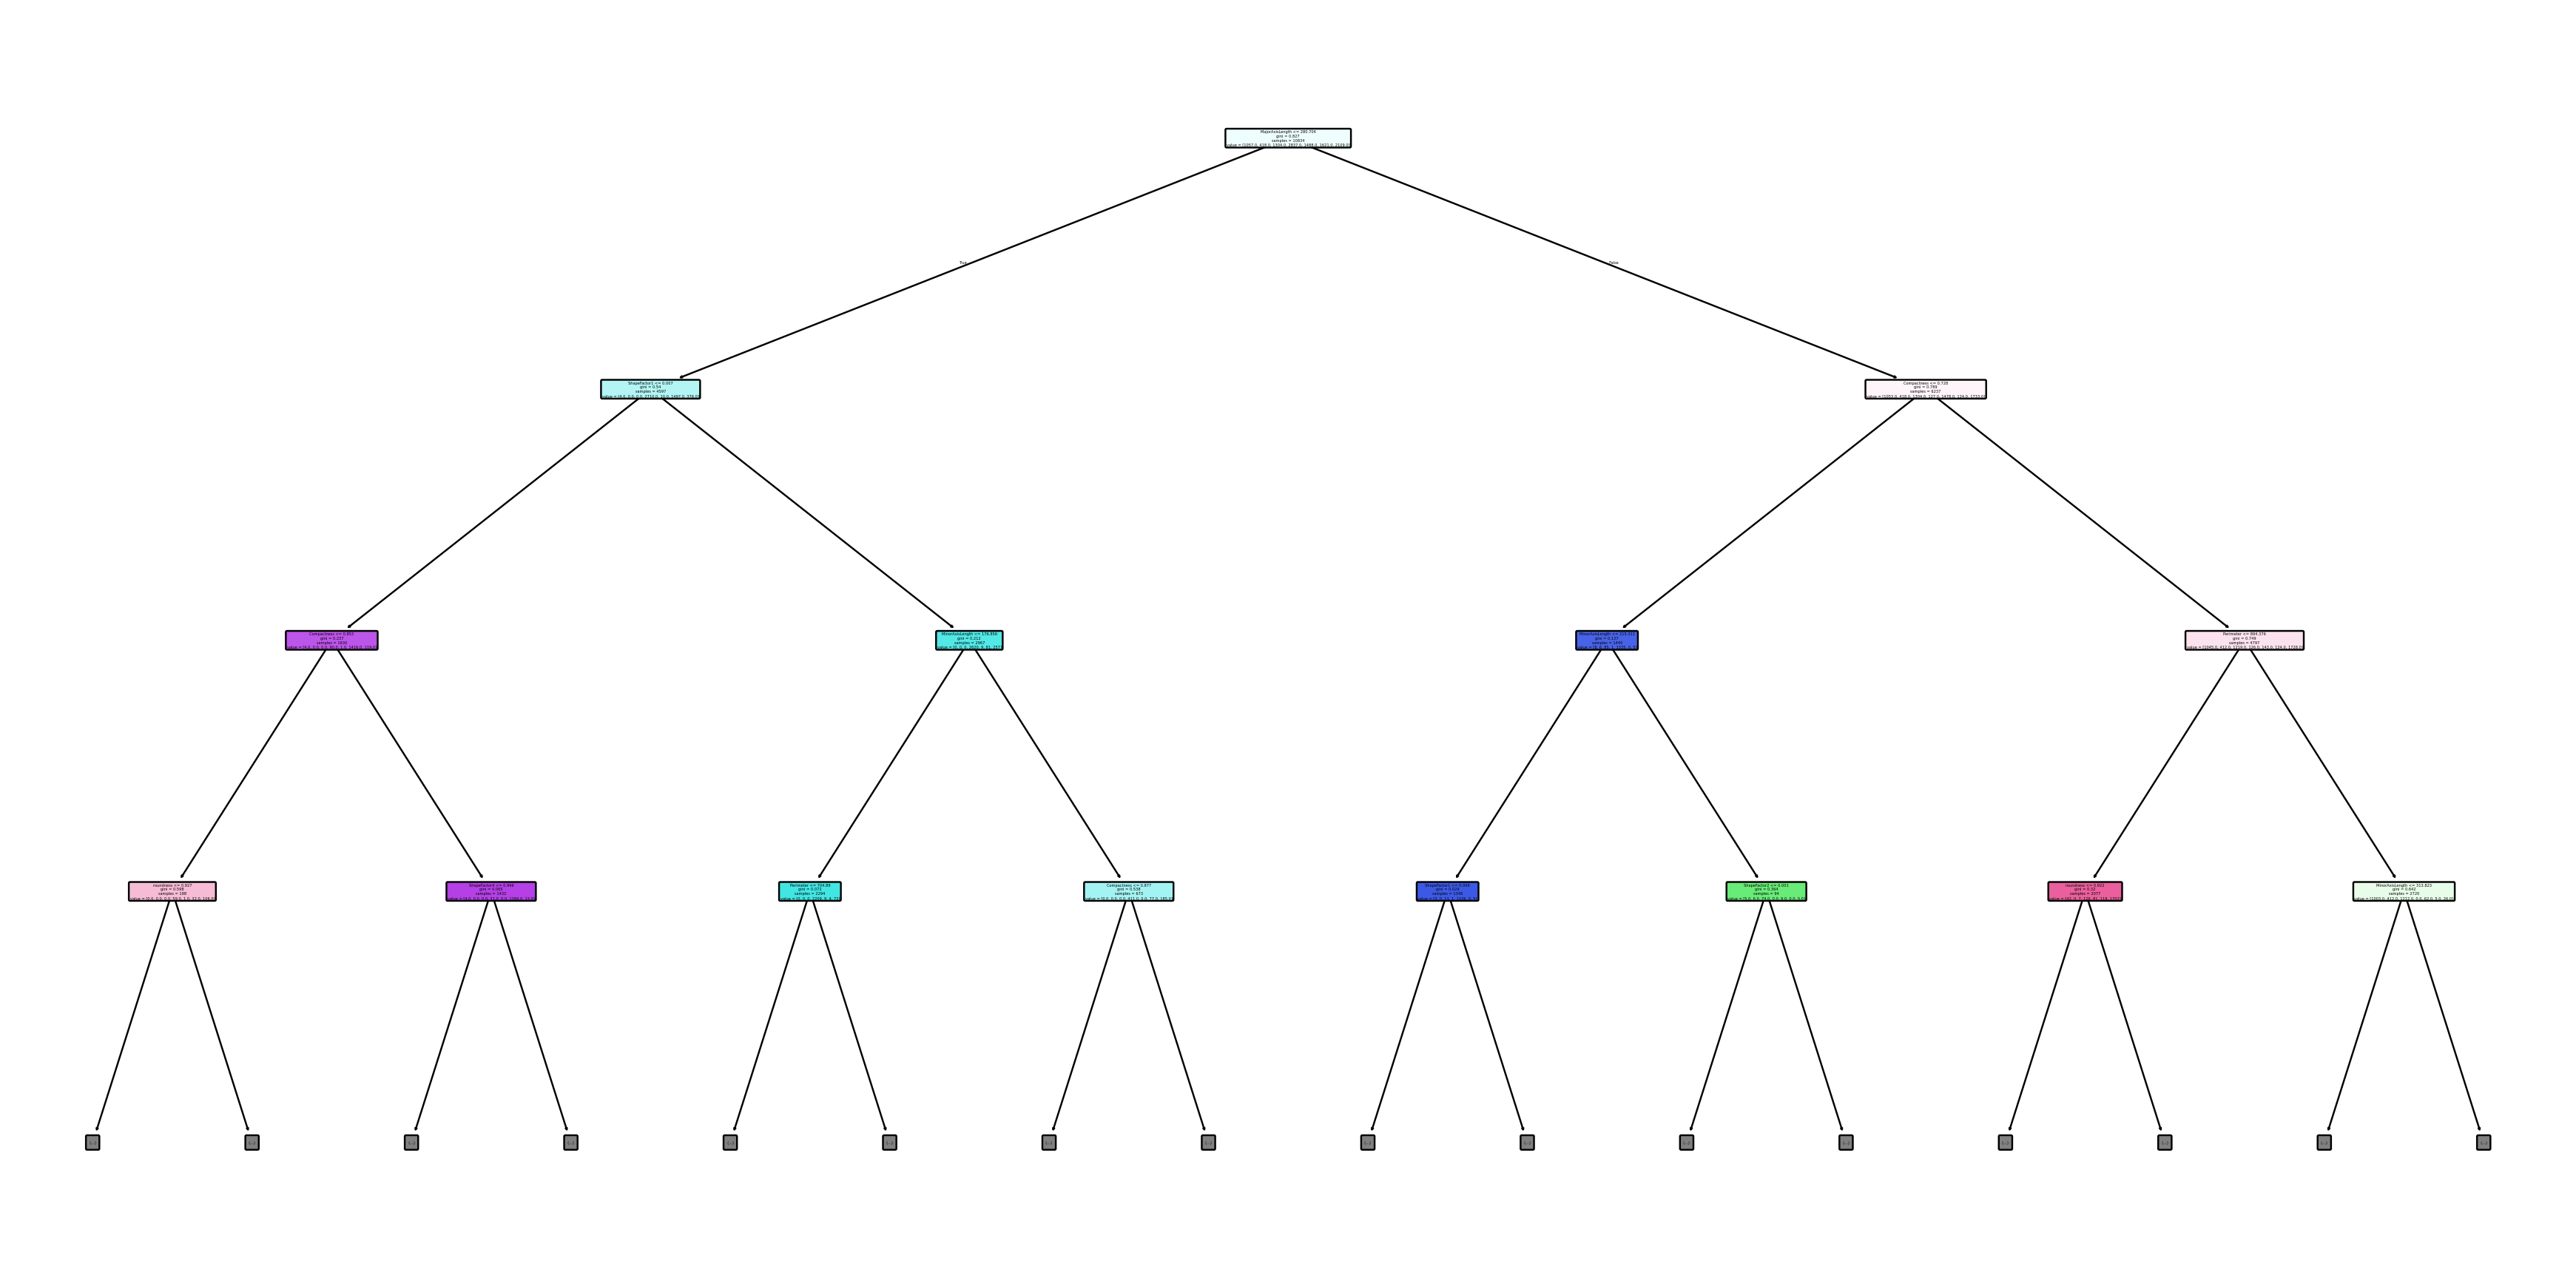

Depth:  27
Acuracy:  0.89


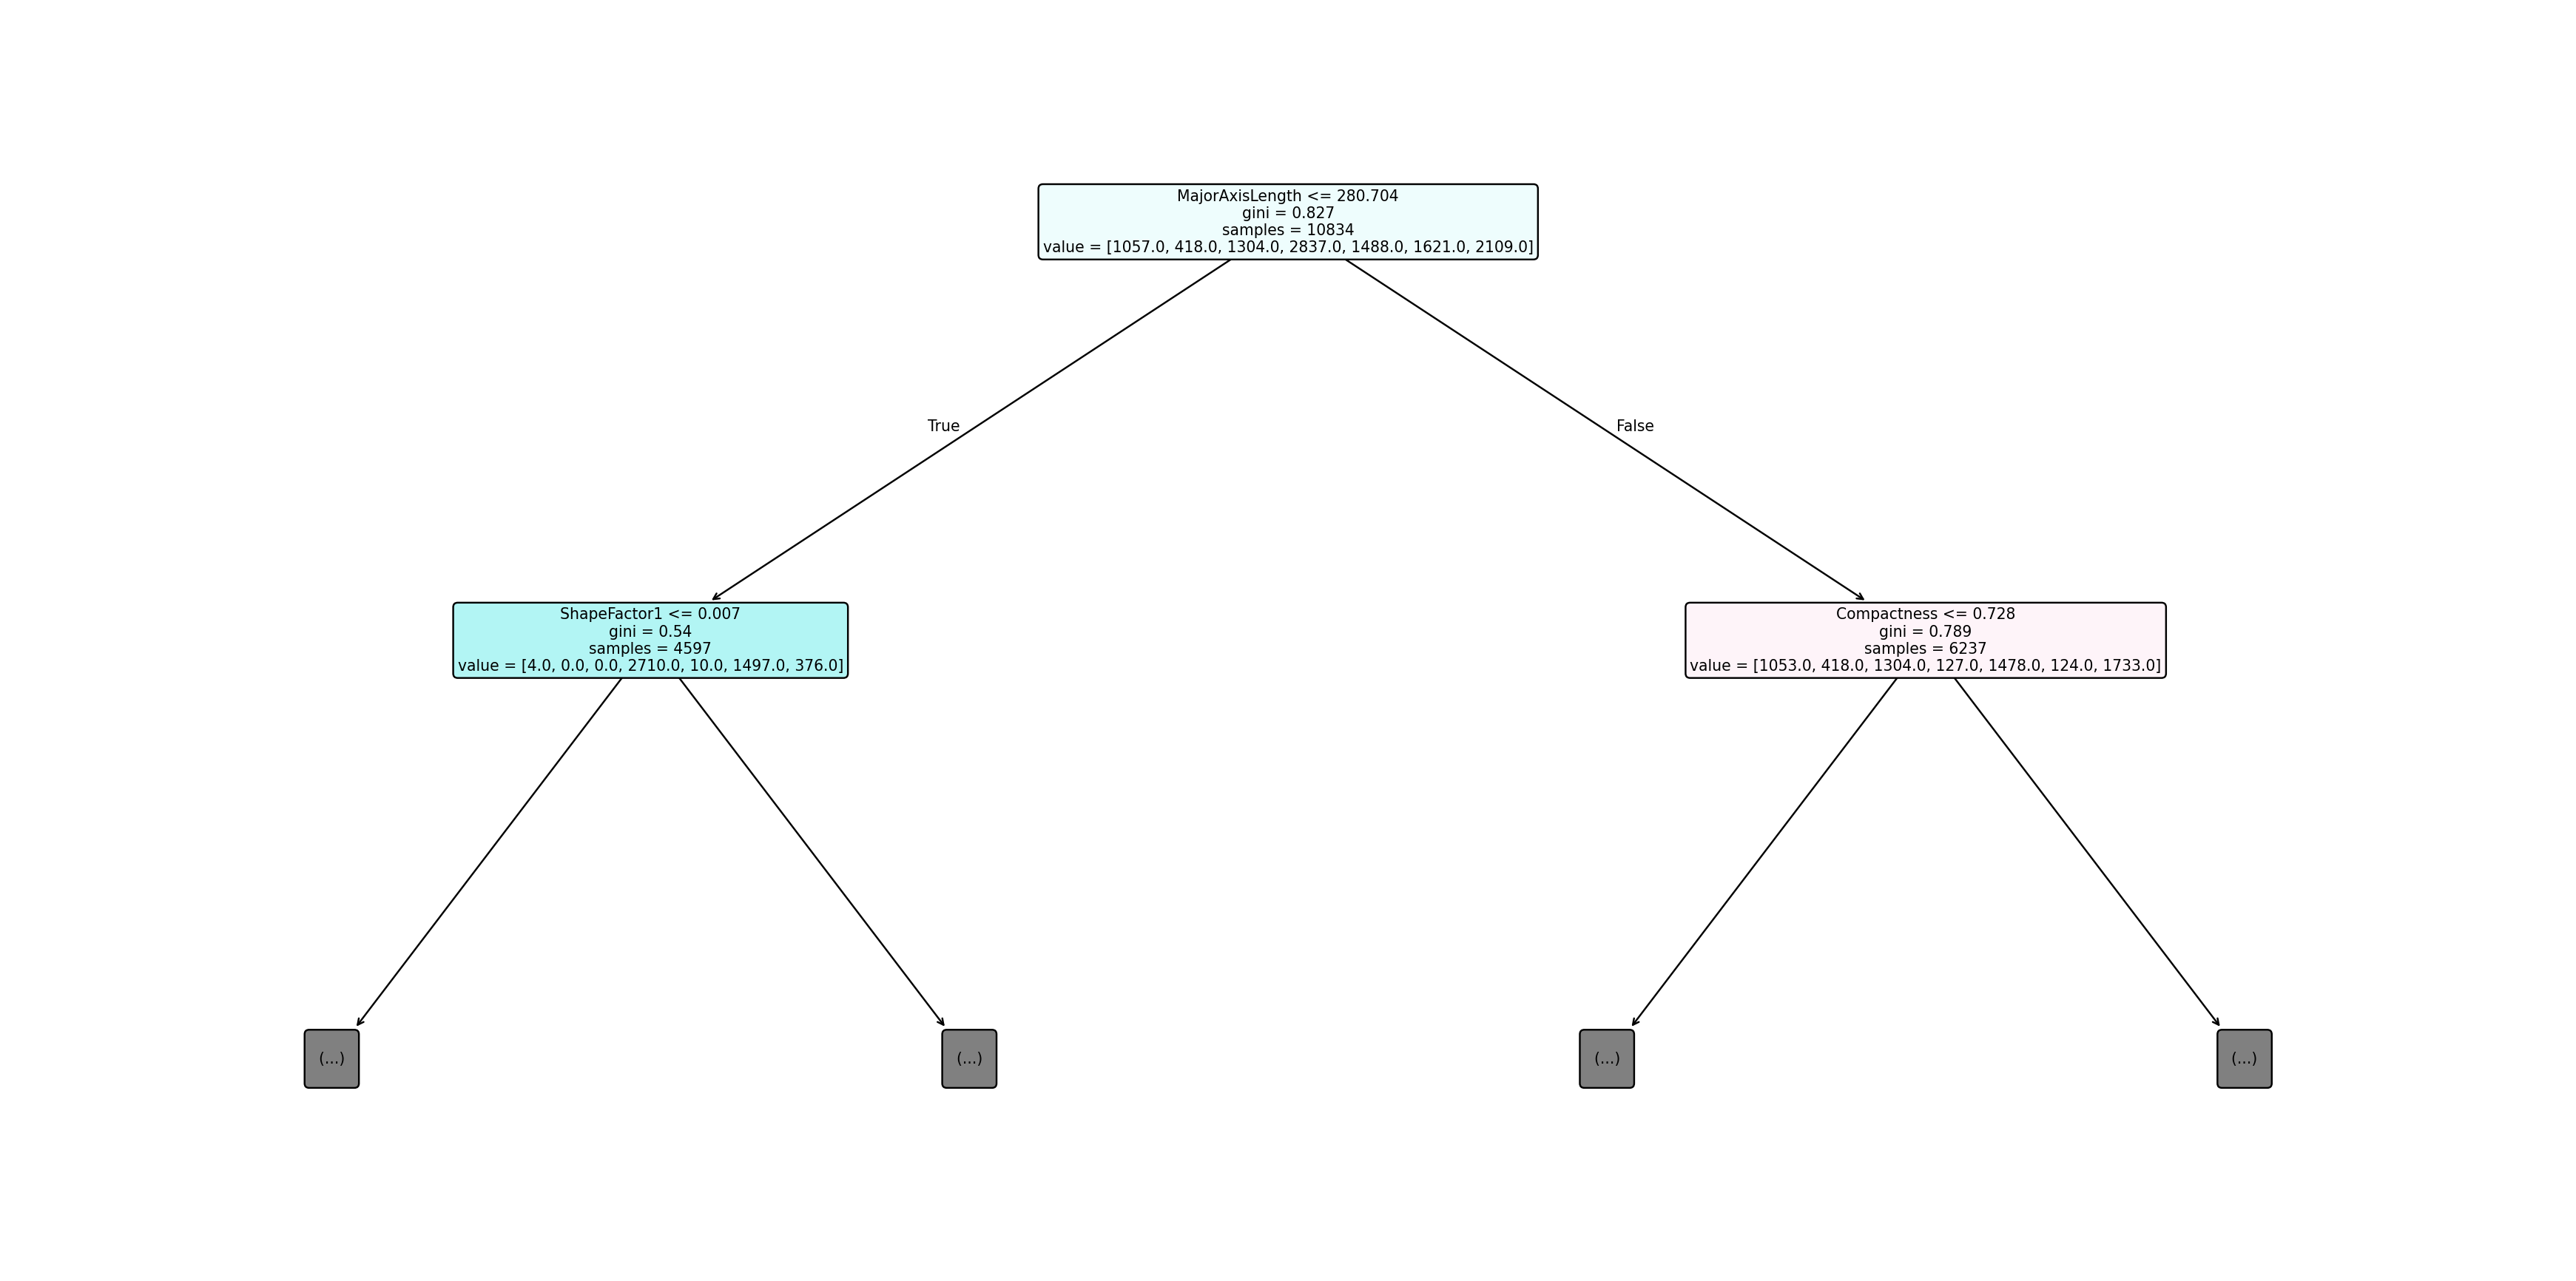

In [113]:
model_summary(dtc, X_train, y_train, X_test, y_test,10)
model_summary(dtc, X_train, y_train, X_test, y_test,5)
model_summary(dtc, X_train, y_train, X_test, y_test,3)
model_summary(dtc, X_train, y_train, X_test, y_test,1)

In [114]:
# using ccp alpha and cost complexitity 
dtc_ccp = dtc.cost_complexity_pruning_path(X_train, y_train)
ccp_aplhas = dtc_ccp['ccp_alphas']
ccp_aplhas

array([0.00000000e+00, 6.15346748e-05, 6.92265091e-05, 7.69183435e-05,
       7.69183435e-05, 7.91160104e-05, 7.91160104e-05, 8.07642607e-05,
       8.20462331e-05, 8.20462331e-05, 8.20462331e-05, 8.30718110e-05,
       8.39109202e-05, 8.39109202e-05, 8.39109202e-05, 8.41577170e-05,
       8.46101778e-05, 8.52018574e-05, 8.52018574e-05, 8.52018574e-05,
       8.52018574e-05, 8.52018574e-05, 8.52018574e-05, 8.52018574e-05,
       8.57090113e-05, 8.61485447e-05, 8.62823157e-05, 8.68724821e-05,
       8.71741226e-05, 8.71741226e-05, 8.71741226e-05, 8.71741226e-05,
       8.74440115e-05, 8.74440115e-05, 8.75277702e-05, 8.79066783e-05,
       8.79066783e-05, 8.83462117e-05, 8.85345831e-05, 8.85887128e-05,
       8.87519348e-05, 8.88834191e-05, 8.88834191e-05, 8.88834191e-05,
       8.93245279e-05, 8.97380674e-05, 8.98073632e-05, 8.99944619e-05,
       9.01622395e-05, 9.01622395e-05, 9.02508564e-05, 9.04182976e-05,
       9.05927157e-05, 9.08132701e-05, 9.09446297e-05, 9.10546877e-05,
      

(array([-50.,   0.,  50., 100., 150., 200., 250., 300., 350., 400., 450.]),
 [Text(-50.0, 0, '−50'),
  Text(0.0, 0, '0'),
  Text(50.0, 0, '50'),
  Text(100.0, 0, '100'),
  Text(150.0, 0, '150'),
  Text(200.0, 0, '200'),
  Text(250.0, 0, '250'),
  Text(300.0, 0, '300'),
  Text(350.0, 0, '350'),
  Text(400.0, 0, '400'),
  Text(450.0, 0, '450')])

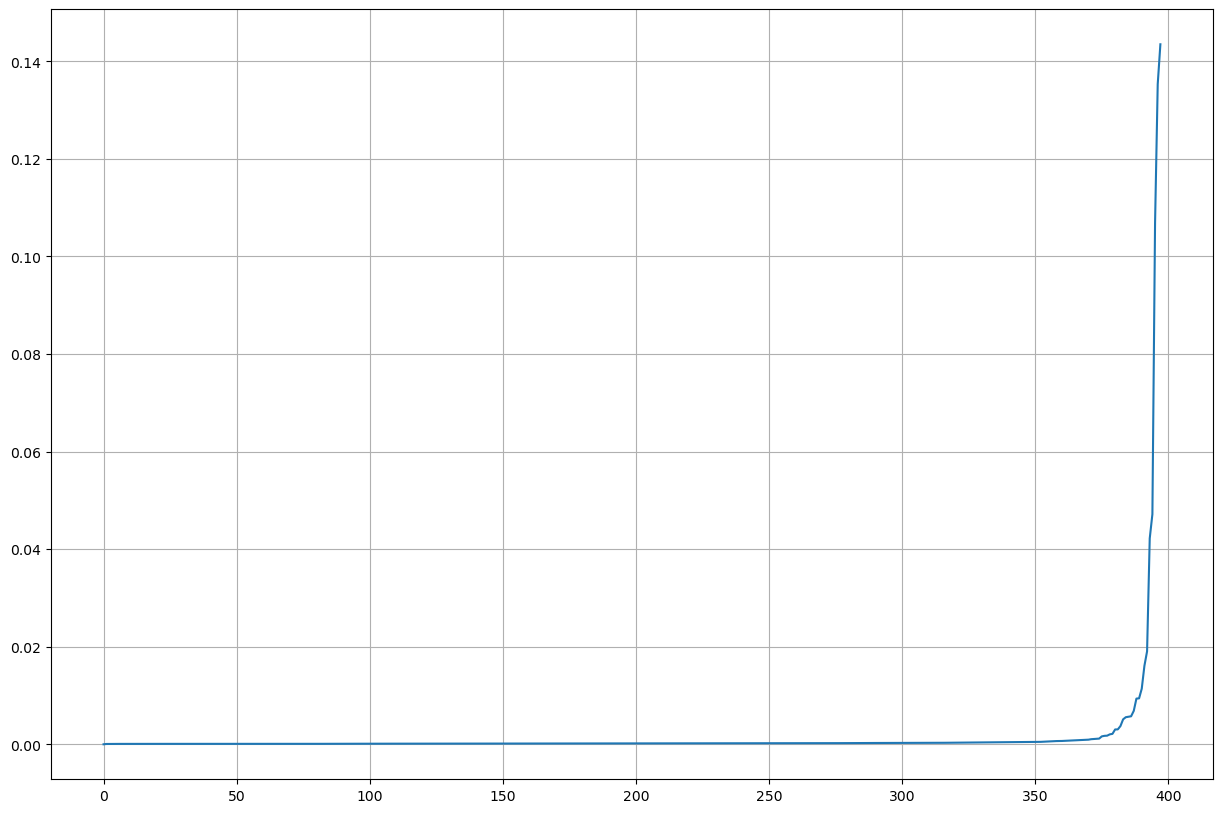

In [115]:

plt.figure(figsize=(15,10))
sns.lineplot(ccp_aplhas)
plt.grid()
plt.xticks()


In [116]:
ccp_aplhas[380]

np.float64(0.003037033030338837)

Depth:  9
Acuracy:  0.89


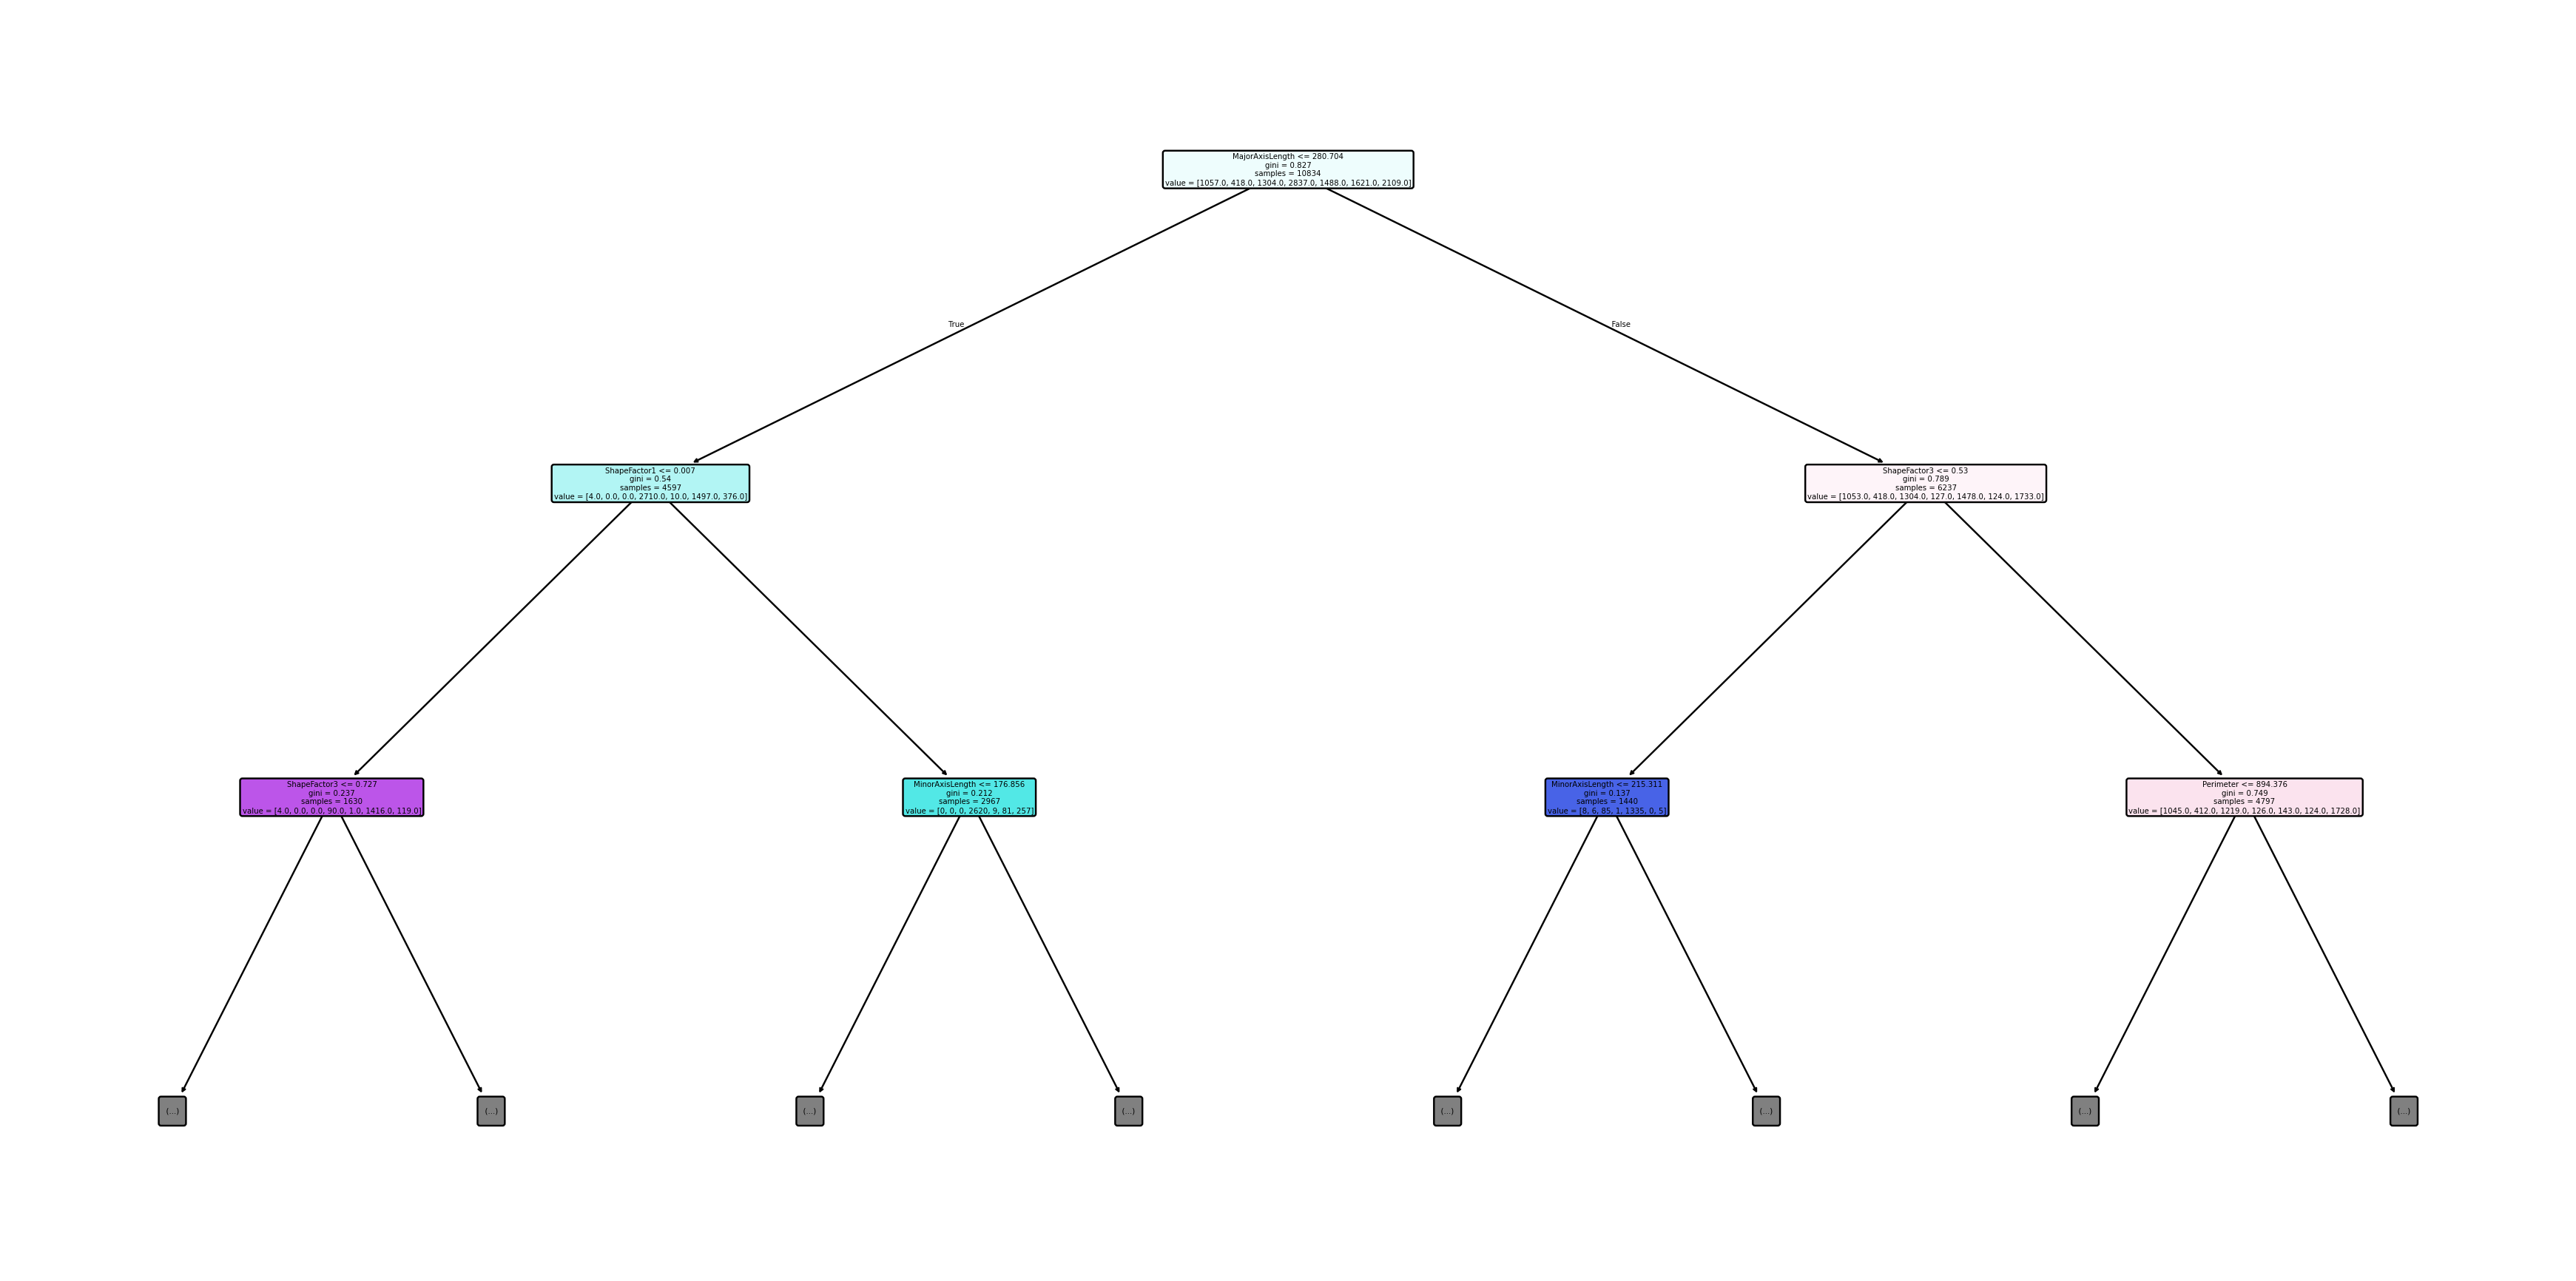

In [117]:
dtc_aplha = DecisionTreeClassifier(ccp_alpha=0.002034087912609433, random_state=42)
model_summary(dtc_aplha, X_train, y_train, X_test, y_test, 2)

In [118]:
from sklearn.model_selection import GridSearchCV
params_grid = {
    'ccp_alpha': ccp_aplhas
}
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid=params_grid, n_jobs=-1, cv=5)

grid.fit(X_train, y_train)
print(f"Best ccp_alpha: {grid.best_params_}")
print(f"Best score: {grid.best_score_:.4f}")

Best ccp_alpha: {'ccp_alpha': np.float64(0.00045798263693881203)}
Best score: 0.9146


In [119]:
# so from what i see the best ccp alpha for the model is 0.00045798 because it is relatively small and gives the most accurate results compared to not using aplha at all 

PART 2 Bagging

In [120]:
#2.5 svm and dt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, BaggingClassifier
from sklearn import svm 
from sklearn.svm import SVC

# bagging classifer
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)

# print(classification_report(y_test, y_pred_bag))
print('Decision Tree Bagging')
print(f'The accuracy of the Decision Tree Bagging Classifier is: {round(bag.score(X_test,y_test),3)}')
print(F'The confusion matrix of it is: \n {confusion_matrix(y_test, y_pred_bag)}')
print('*'*80)


# svm
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

bag_2 = BaggingClassifier(
    estimator=SVC(random_state=42),
    bootstrap=True,
    n_estimators=50,
    n_jobs=-1,
    random_state=42

)
bag_2.fit(X_train_scaled, y_train)
y_pred_svm = bag_2.predict(X_test_scaled)
print('SVM')
print(F'The accuaracy score of the SVM bagging model is: {round(bag_2.score(X_test_scaled, y_test),3)}')
print(F'Confusion matrix of SVM model bagging \n {confusion_matrix(y_test, y_pred_svm)}')

# from what we can see in the output using bagging SVM is more accurate than using the Decision Tree 

Decision Tree Bagging
The accuracy of the Decision Tree Bagging Classifier is: 0.915
The confusion matrix of it is: 
 [[239   0  15   1   1   3   6]
 [  0 104   0   0   0   0   0]
 [ 13   0 303   0   5   2   3]
 [  0   0   0 649   0  12  48]
 [  0   0  11   5 349   0   7]
 [  4   0   0   7   0 389   6]
 [  4   0   0  60   7  10 446]]
********************************************************************************
SVM
The accuaracy score of the SVM bagging model is: 0.921
Confusion matrix of SVM model bagging 
 [[236   0  17   0   1   4   7]
 [  0 104   0   0   0   0   0]
 [  7   0 309   0   6   2   2]
 [  0   0   0 648   0  13  48]
 [  1   0   7   5 351   0   8]
 [  4   0   0   6   0 386  10]
 [  3   0   1  48   6   7 462]]


In [121]:
#2.6 rfc
# baseline or default rfc
rfc = RandomForestClassifier(random_state=42, n_jobs=-1)
rfc.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)
print(F'Normal rfc accuray is {rfc.score(X_test,y_test)}')
confusion_matrix(y_test, y_pred_rfc)

# n_estimators changing
n_estimators_multi = [15, 30, 50, 150, 200]
estimator_accuracy = []

for estimator in n_estimators_multi:
    rfc2 = RandomForestClassifier(n_jobs=-1, random_state=42, n_estimators=estimator)
    rfc2.fit(X_train, y_train)
    y_pred_rfc2 = rfc2.predict(X_test)
    estimator_accuracy.append(round(rfc2.score(X_test, y_test),5))

estimator_accuracy

Normal rfc accuray is 0.9198966408268734


[0.91805, 0.91805, 0.91768, 0.91879, 0.91953]

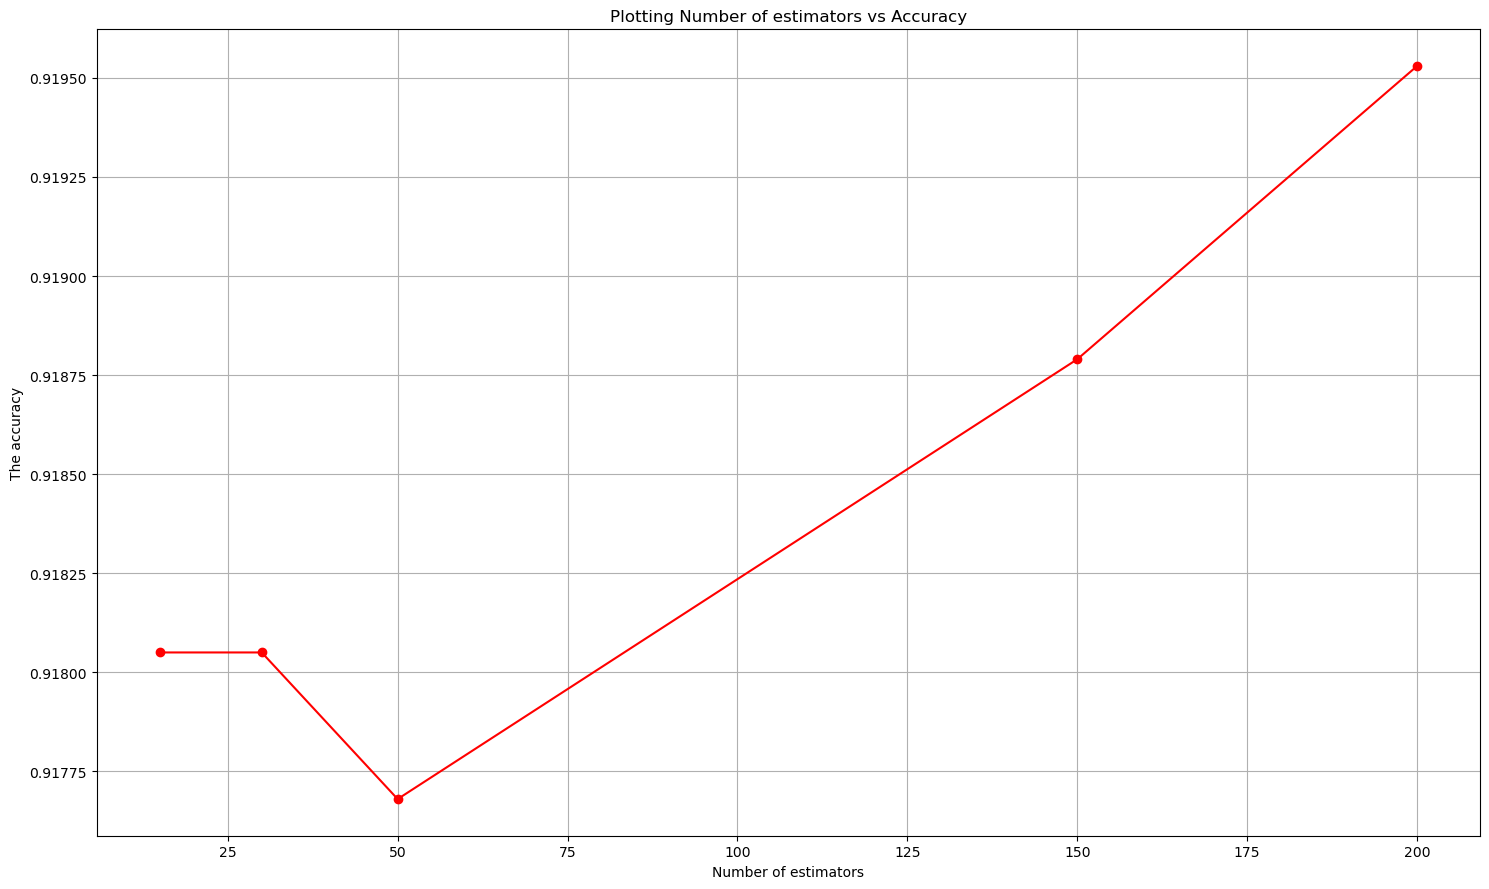

In [122]:
#plotting 
plt.figure(figsize=(15,9))
plt.plot(n_estimators_multi, estimator_accuracy, color='red', marker='o')
plt.xlabel('Number of estimators')
plt.ylabel('The accuracy')
plt.title('Plotting Number of estimators vs Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()
# from the plot we can see if the number of estimators is low there is a plateau but in general for estimators reach the number 50 it keeps on increasing

In [123]:
max_features = ['log2', 'sqrt',7]
max_feature_accuracy = []

for max in max_features:
    rfc3 = RandomForestClassifier(n_jobs=-1, random_state=42, max_features=max)
    rfc3.fit(X_train, y_train)
    y_pred_rfc3 = rfc3.predict(X_test)
    max_feature_accuracy.append(round(rfc3.score(X_test,y_test),5))

max_feature_accuracy
# we notice that log2 and sqrt provide the best results with the exact same accuracy score whilst 7 is on the lower end but still highly accurate

[0.9199, 0.9199, 0.91768]

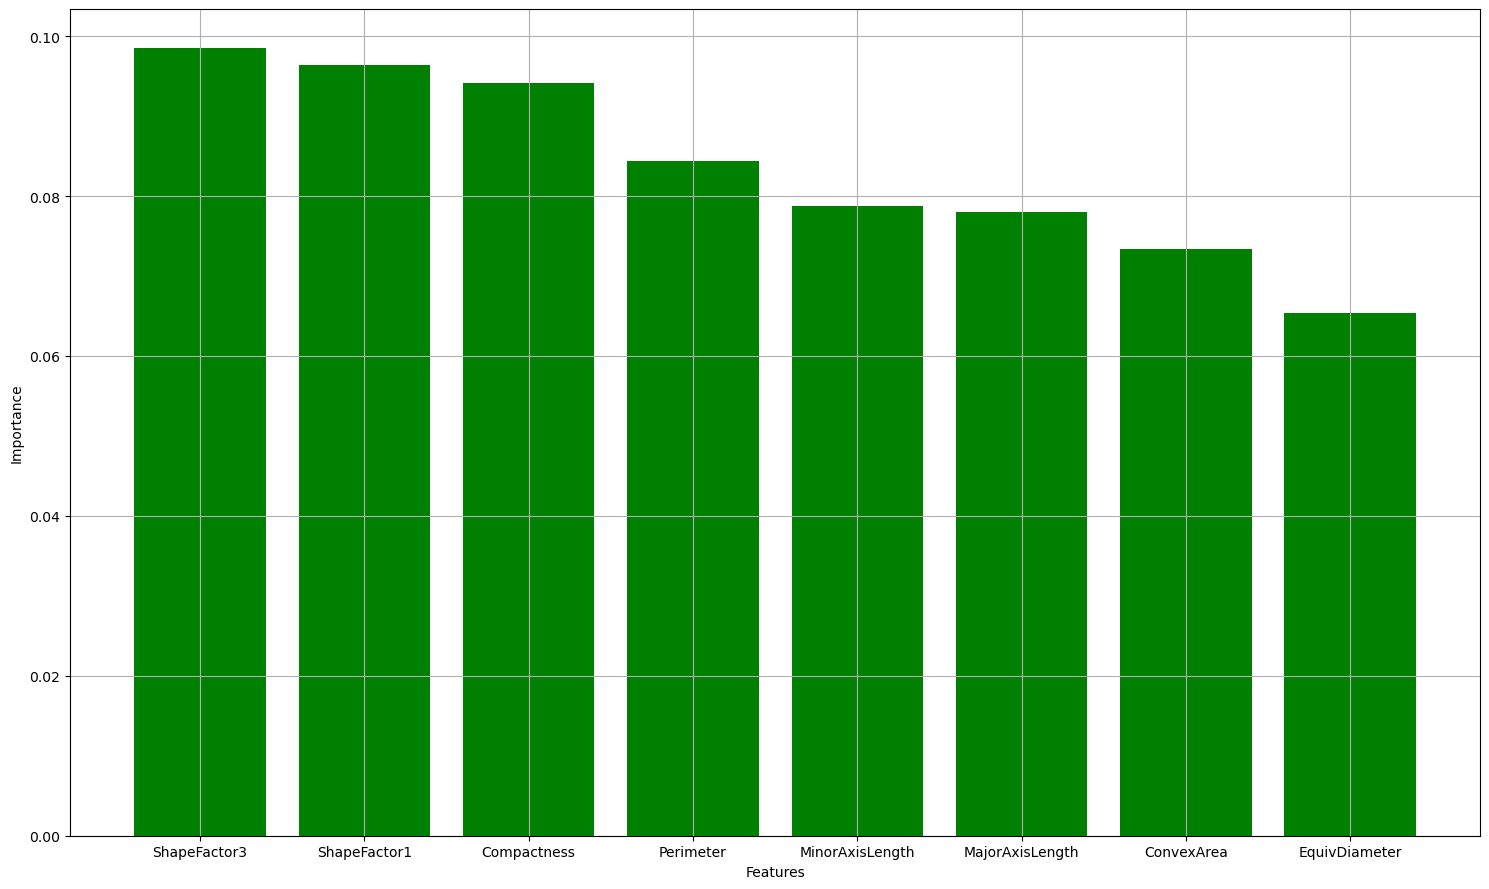

In [124]:
best_rfc = RandomForestClassifier(random_state=42, n_jobs=-1, max_features='sqrt', n_estimators=200)
best_rfc.fit(X_train, y_train)
y_predbest = best_rfc.predict(X_test)
best_rfc.score(X_test, y_test)

top8_features = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rfc.feature_importances_}).sort_values('Importance', ascending=False)
top8 = top8_features[:8]

plt.figure(figsize=(15,9))
plt.bar(top8['Feature'], top8['Importance'], color='green')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.tight_layout()
plt.grid(True)
plt.show()

PART 3 GRADIENT BOOSTING

In [ ]:
# gradient boosting 3.7
from sklearn.ensemble import GradientBoostingClassifier

multi_n_estimators = [20, 70, 110, 140]
accuracy_estimators = [] 

for estimate in multi_n_estimators:
    gbc = GradientBoostingClassifier(random_state=42, n_estimators=estimate, learning_rate=0.1)
    gbc.fit(X_train, y_train)
    y_pred_gbc = gbc.predict(X_test)
    accuracy = gbc.score(X_test, y_test)
    accuracy_estimators.append(accuracy)

accuracy_estimators


[0.9132521225544481,
 0.9191583610188261,
 0.9165743816906607,
 0.9154669619785899]

In [134]:
# try different learning rates
learning_rates = [0.1, 0.35, 0.50, 0.85]
accuracy_learn = []

best_model = None
best_value = None
best_accuracy = 0

for learn in learning_rates:
    gbc = GradientBoostingClassifier(random_state=42, learning_rate=learn, n_estimators=70)
    gbc.fit(X_train, y_train)
    y_pred_learn = gbc.predict(X_test)
    accuracy = gbc.score(X_test, y_test)
    accuracy_learn.append(accuracy)

    if accuracy > best_accuracy:
        best_accuracy= accuracy
        best_model = gbc
        best_value = learn
    
    
print(accuracy_learn)
print('Best learning rate is ', best_value)
print(confusion_matrix(y_test, best_model.predict(X_test)))

[0.9191583610188261, 0.9121447028423773, 0.9136212624584718, 0.899593946105574]
Best learning rate is  0.1
[[234   0  17   0   1   3  10]
 [  0 104   0   0   0   0   0]
 [  8   0 307   0   6   2   3]
 [  0   0   0 654   2  10  43]
 [  0   0   8   5 349   0  10]
 [  7   0   0   6   0 384   9]
 [  3   0   0  51   7   8 458]]


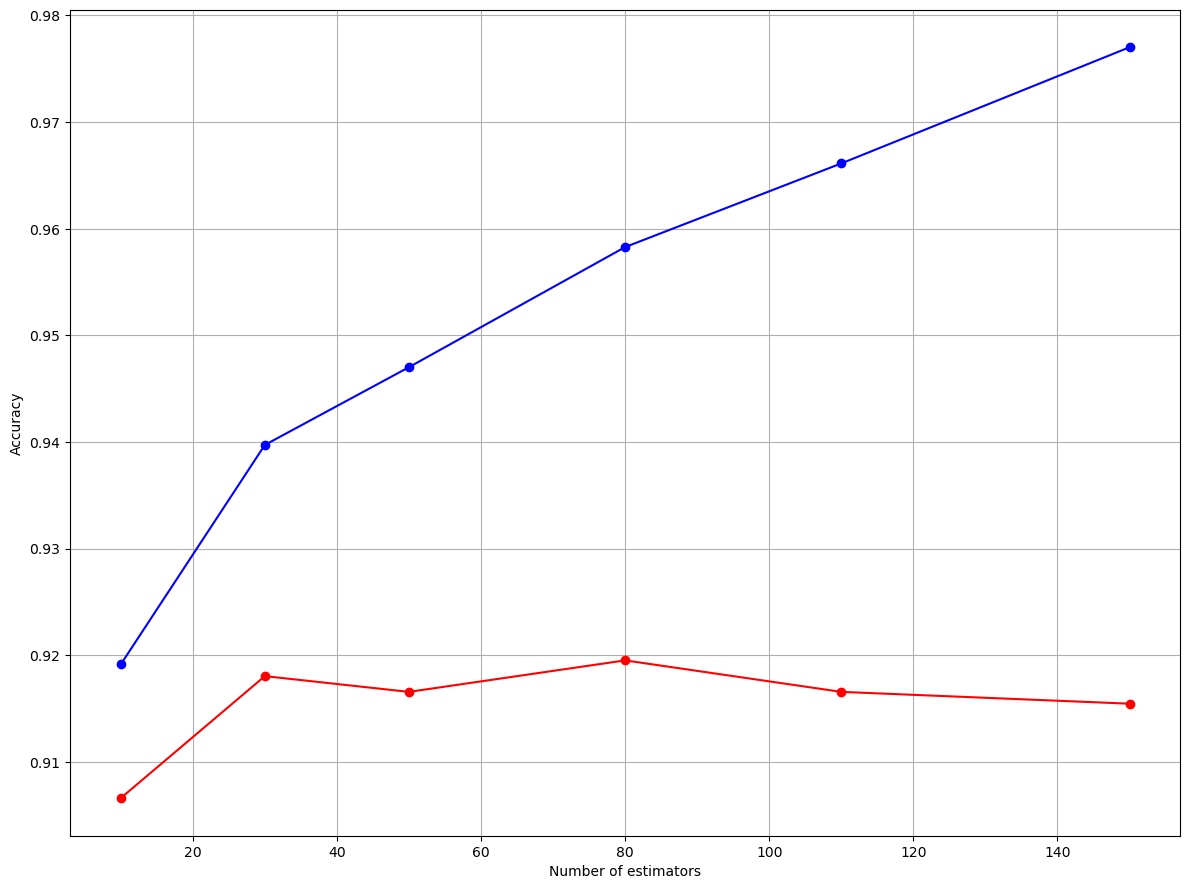

In [135]:
# plotting learning curve
n_ranges = [10,30,50,80,110,150]
train_acc = []
test_acc = []

for n in n_ranges:
    gbc3 = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=best_value,
        random_state=42
    )
    gbc3.fit(X_train, y_train)

    train_acc.append(gbc3.score(X_train, y_train))
    test_acc.append(gbc3.score(X_test, y_test))

plt.figure(figsize=(12,9))
plt.plot(n_ranges, train_acc, marker='o', color='blue', label='Training accuracy')
plt.plot(n_ranges, test_acc, marker='o', color='red', label='Training accuracy')
plt.xlabel('Number of estimators')
plt.ylabel('Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# what i see for the train it keeps on increasing as number of estimators increase it went from around 0.9185 to almost 0.98, 
# as for the test line which is red its best accuracy came with 80 estimators around 0.92 which is close to the default 100 and it decreases after that

# the training accuracy is clearly the one overfitting as it just keeps increasing

In [140]:
# 3.8 xgboost 70 n estimators and learning curve = 0.1
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, n_estimators=70, learning_rate=0.1)

xgb.fit(X_train, y_train)
y_pred_XG = xgb.predict(X_test)
print(accuracy_score(y_test, y_pred_XG))
confusion_matrix(y_test,y_pred_XG)


0.9195275009228497


array([[237,   0,  16,   1,   1,   2,   8],
       [  0, 104,   0,   0,   0,   0,   0],
       [  8,   0, 306,   0,   7,   2,   3],
       [  0,   0,   0, 654,   0,  12,  43],
       [  1,   0,   8,   4, 350,   0,   9],
       [  8,   0,   0,   6,   0, 383,   9],
       [  2,   0,   1,  52,   8,   7, 457]])

In [ ]:
subsample = [0.6, 0.8, 1.0]
subsample_acc = []

for sub in subsample:
    xgb2 = XGBClassifier(
        subsample=sub, n_estimators=70, 
        learning_rate=0.1, random_state=42)
    xgb2.fit(X_train,y_train)
    subsample_acc.append(accuracy_score(y_test, xgb2.predict(X_test)))

print(subsample_acc)

# the best accuracy waas achieved with 80% of the sample with 0.921 because it provided enough diversity, and still has high enough information
#Bagging creates bootstrap samples to train independent models and then aggregates and takes majority vote
# subsample parameter gives each tree different information which increases the diversity so each tree is different so correlation reduces

#

[0.9187892211148025, 0.9210040605389442, 0.9195275009228497]


In [ ]:
# 3.9
# from what i have seen the best results i got was form xgboost and svm with bagging both 0.921
# bagging reduces the variance, while boosting reduces bias 
# random forest is very quick compared to normal bagging and boosting and achieved accuracy of 0.92
# for me the xgboost is better because it took less time to run and you dont need to scale the data
